In [ ]:
# OLD 7 TOOLS (TANPA CONTOL CHART)

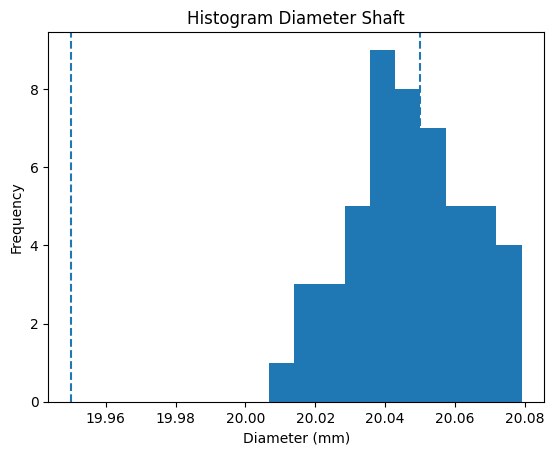

In [ ]:
# 1. HISTOGRAM
# visualisasi distribusi data pengukuran diameter lebar piston misalnya
# Data diameter (mm, 50 sampel)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
diameter = np.random.normal(loc=20.045, scale=0.015, size=50)

plt.figure()
plt.hist(diameter, bins=10)
plt.axvline(19.95, linestyle='--')
plt.axvline(20.05, linestyle='--')
plt.title("Histogram Diameter Shaft")
plt.xlabel("Diameter (mm)")
plt.ylabel("Frequency")
plt.show()

# Interpretasi:
# terlihat distribusi normal dengan sebagian besar data berada di sekitar mean 20.04 mm
# batas spesifikasi berada di 19.95 mm dan 20.05 mm
# banyak data berada melebihi batas spesifikasi atas
# kemungkinan lebar piston terlalu lebar dan tidak sesuai spesifikasi toleransi
# sebaran data cukup rapat, meunjukkan proses produksi cukup konsisten dan tidak banyak variasi
# Aksi: process centering, bukan inspeksi

In [ ]:
# 2. CHECK SHEET
# check sheet untuk mencatat jenis cacat pada produk

# Jenis cacat dicatat manual oleh QC:

# Defect       Type     Count      total
#           senin   selasa   rabu
# Oversize	 34       20      10     64
# Undersize	 22       25      15     62
# Scratch	 28       10      12     50
# Burr	     19       15      20     54
# OK	     17       10      20     47
# total     120       80      77     277

# Interpretasi:
# Mayoritas masalah ada pada oversize dan undersize dengan total 126 cacat selama 3 hari produksi, dan hari senin dan selasa memiliki jumlah cacat tinggi
# Check sheet tidak menyimpulkan apa pun
# Kalau klasifikasi salah → Pareto menyesatkan

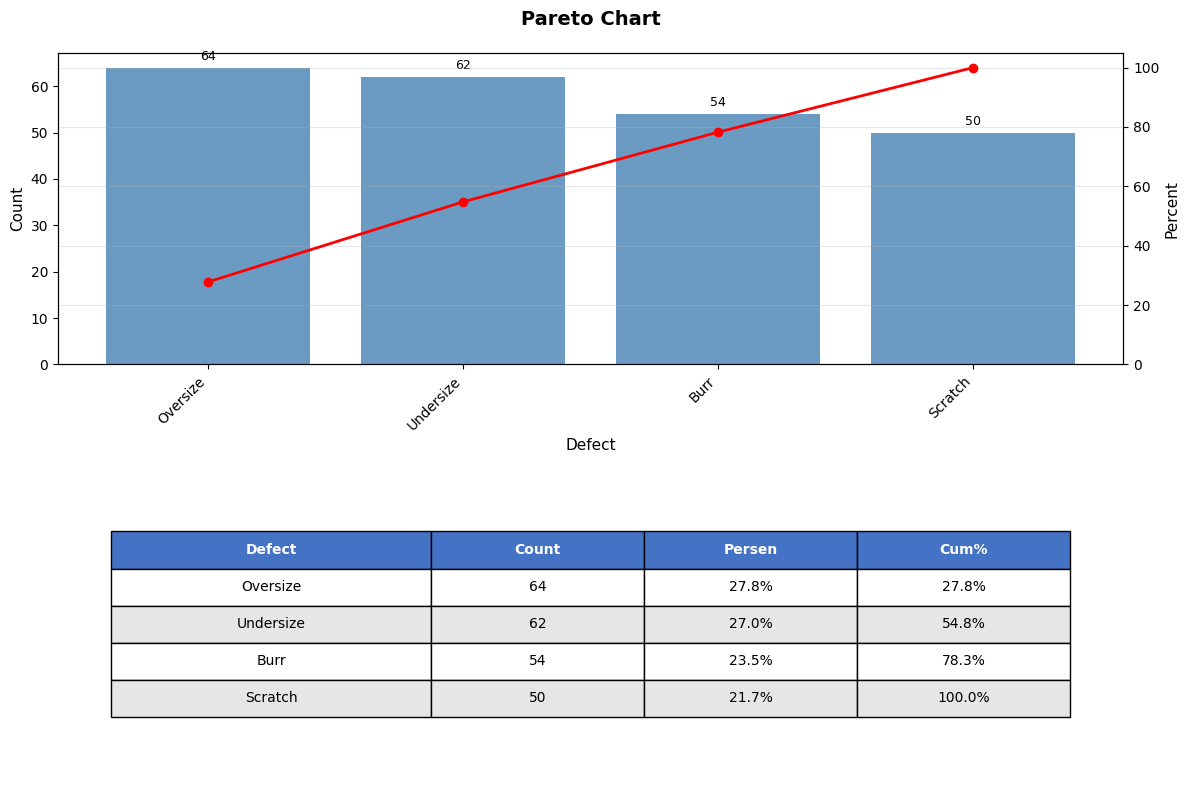


Data Pareto:
   Defect  Count    Persen       Cum%
 Oversize     64 27.826087  27.826087
Undersize     62 26.956522  54.782609
     Burr     54 23.478261  78.260870
  Scratch     50 21.739130 100.000000


In [ ]:
# 3. PARETO CHART

import pandas as pd

# defect data dari check sheet
data = {
    "Defect": ["Oversize", "Undersize", "Scratch", "Burr"],
    "Count": [64, 62, 50, 54]
}

df = pd.DataFrame(data)

# Urutkan dari frekuensi terbesar
df = df.sort_values('Count', ascending=False).reset_index(drop=True)

# Hitung persen dan kumulatif persen
df['Persen'] = (df['Count'] / df['Count'].sum()) * 100
df['Cum%'] = df['Persen'].cumsum()

# Buat figure dengan 2 subplot (chart dan tabel)
fig = plt.figure(figsize=(12, 8))

# Subplot untuk chart
ax1 = plt.subplot(2, 1, 1)
ax2 = ax1.twinx()

# Plot bar chart
x_pos = np.arange(len(df))
bars = ax1.bar(x_pos, df['Count'], color='steelblue', alpha=0.8)
ax1.set_xlabel('Defect', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df['Defect'], rotation=45, ha='right')

# Plot line chart untuk kumulatif
line = ax2.plot(x_pos, df['Cum%'], color='red', marker='o', linewidth=2, markersize=6)
ax2.set_ylabel('Percent', fontsize=11)
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3, axis='y')

# Tambahkan nilai di atas bar
for i, v in enumerate(df['Count']):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=9)

plt.title('Pareto Chart', fontsize=14, fontweight='bold', pad=20)

# Subplot untuk tabel
ax_table = plt.subplot(2, 1, 2)
ax_table.axis('tight')
ax_table.axis('off')

# Format data untuk tabel
table_data = []
for i in range(len(df)):
    row = [
        df['Defect'][i],
        df['Count'][i],
        f"{df['Persen'][i]:.1f}%",
        f"{df['Cum%'][i]:.1f}%"
    ]
    table_data.append(row)

# Buat tabel
table = ax_table.table(cellText=table_data,
                       colLabels=['Defect', 'Count', 'Persen', 'Cum%'],
                       cellLoc='center',
                       loc='center',
                       colWidths=[0.3, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style untuk header
for i in range(4):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style untuk baris data
for i in range(1, len(df) + 1):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E7E6E6')
        else:
            table[(i, j)].set_facecolor('white')

plt.tight_layout()
plt.show()

# Tampilkan DataFrame
print("\nData Pareto:")
print(df.to_string(index=False))

# Interpretasi Engineering
# jenis cacat oversize dan undersize memiliki frekuensi cacat paling tinggi yaitu sebanyak 64(27.8%) dan 62(26.7%)
# terlihat kumulatif persentase untuk jenis cacat oversize, underize, dan burr sudah mencapai 78.3%
# terlihat juga line merah mencapai titik 80% pada jenis cacat burr (3 jenis cacat teratas)
# artinya, 80% masalah kualitas disebabkan oleh 3 jenis cacat utama tersebut
# tindakan perbaikan harus difokuskan pada pengurangan 3 jenis cacat terbesar tersebut

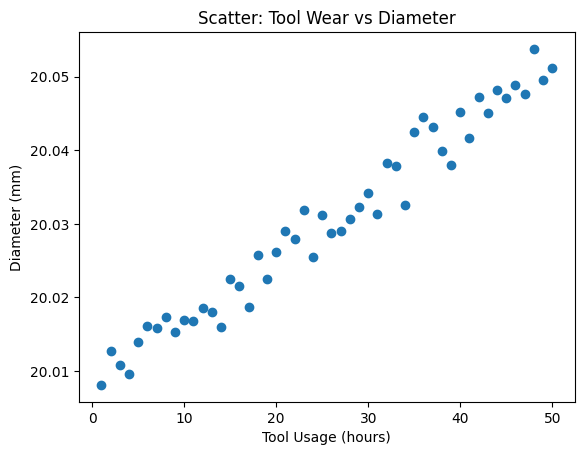

In [ ]:
# 4. SCATTER DIAGRAM
# untuk melihat hubungan antara 2 variabel
# Jam pemakaian tool vs diameter

tool_hours = np.arange(1, 51)
diameter_tool = 20.01 + 0.0008 * tool_hours + np.random.normal(0, 0.003, 50)

plt.figure()
plt.scatter(tool_hours, diameter_tool)
plt.xlabel("Tool Usage (hours)")
plt.ylabel("Diameter (mm)")
plt.title("Scatter: Tool Wear vs Diameter")
plt.show()

# intepretasi:
# terlihat tren kenaikan diameter seiring bertambahnya jam pemakaian tool
# semakin lama tool dipakai, diameter semakin besar
# kalau diameter ingin distabilkan, perlu ada pergantian tool secara berkala

In [ ]:
# 5. CAUSE–EFFECT DIAGRAM (Fishbone – teks)
# untuk menganalisis penyebab potensial dari masalah kualitas
# ada 5M+1E yaitu man, machine, method, material, measurement, dan environment

# Diameter Oversize
# ------------------------------------------------
# Man        | Machine     | Method
# - Operator | - Tool wear | - No warm-up
# - Training | - Runout    | - Offset manual
#------------------------------------------------ Cacat Oversize
# Material   | Measurement | Environment
# - Hardness | - Cal drift | - Temp change
# ------------------------------------------------

# Interpretasi:
# dari sisi manusia terdapat kemungkinan operator kurang terlatih sehingga terjadi cacat oversize
# dari mesin, tool yang sudah aus (tool wear) dapat menyebabkan diameter menjadi oversize
# dari metode, tidak adanya prosedur warm-up sebelum produksi dan offset manual dapat mengebabkan variasi diameter
# sisanya sama

In [ ]:
# 6. FLOWCHART 
# untuk memetakan proses produksi dan mengidentifikasi potensi sumber cacat

# Raw Material
#      ↓
#   Turning
#      ↓
# Manual Handling (open bin)
#      ↓
#  Inspection
#      ↓
#   Packing

# Interpretasi
# ternyata di proses manual handling ada masalah no warm up sehingga tool belum stabil dan menyebabkan cacat oversize
# Masalah bukan di mesin
# Flowchart sering membuka blind spot

In [ ]:
# NEW 7 TOOLS

In [ ]:
# AFFINITY DIAGRAM
# (Mengubah chaos → tema besar)
# Input mentah (VOC, operator, QC, maintenance)
# kumpulan masalah kualitas dari berbagai sumber yang tampak acak dan tidak terstruktur dan di strukturkan menjadi tema besar

# contoh masalah kualitas acak:
# Tool cepat aus, Offset sering diubah, Operator baru bingung setting, Banyak part lecet, Bin terbuka, Target output tinggi
# QC overload, dan Tidak ada standar tool life

# Affinity grouping (diagram teks)
# [PROCESS CONTROL]
# - Offset sering diubah
# - Tidak ada standar tool life
# [PEOPLE]
# - Operator baru
# - Training kurang
# [EQUIPMENT]
# - Tool cepat aus
# [HANDLING]
# - Bin terbuka
# - Banyak part lecet
# [MANAGEMENT]
# - Target output tinggi
 
# Interpretasi
# Masalah bukan tunggal
# Tapi tema dominan = process control & handling
# Ini menentukan scope improvement, bukan solusi teknis detail
# Aksi: lanjut ke hubungan sebab–akibat antar tema

In [ ]:
# INTERRELATIONSHIP DIGRAPH
# (Menentukan driver utama)
# Diagram sebab–akibat tapi bukan fishbone

# Tool wear  ──▶ Offset drift ──▶ Oversize ──▶ Rework ──▶ Overtime
#    │                                               │
#    └──────────────▶ Operator stress ◀─────────────┘

# Interpretasi Engineering
# Tool wear = driver utama
# Overtime & stress = efek, bukan akar
# Kalau fokus ke lembur → salah sasaran
# Aksi: improvement harus dimulai dari tool life control

# CATATAN PENTING:
# MIRIP DIAGRAM SIMPAL KAUSAL DI MATA KULIAH DINAMIKA SISTEM
# contoh: cacat disebabkan oleh operator strees, operator stress disebabkan lembur, operator stress juga disebabkan tekanan target produksi
# lembur disebabkan rework, rework disebabkan cacat

In [ ]:
# TREE DIAGRAM
# (Goal → aksi operasional)
# untuk memecah goal menjadi aksi-aksi nyata yang bisa diimplementasikan
# ada 2 tipe yaitu tipe tree dan cascade

# contoh tujuan
# Reduce reject 30% dalam 3 bulan

# tipe tree:
# Reduce Reject
# ├── Control Diameter
# │   ├── Standar tool life
# │   ├── Offset rule
# │   └── SPC monitoring
# │
# └── Reduce Scratch
#     ├── Tray pelindung
#     ├── Redesign flow
#     |-- Handling SOP

# Interpretasi Engineering
# terlihat goal untuk mengurangi cacat 30% dalam 3 bulan menjadi 2 sub-goal yaitu mengontrol diameter dan mengurangi scratch
# untuk mengontrol diameter ada 3 aksi nyata yang bisa diimplementasikan seperti membuat standar tool life, offset rule, dan monitoring SPC
# untuk mengurangi scratch ada 3 aksi nyata yaitu tray pelindung, redesign flow, dan handling SOP
# fokus ke control diameter dulu karena kontribusi terbesar

# tipe cascade
# reduce reject -> control diameter -> standar tool life
# sama seperti tipe tree tapi fokus ke 1 jalur saja

In [ ]:
# MATRIX DIAGRAM
# (Hubungan antar dimensi)
# Customer requirement vs Process step

# Requirement \ Process     Turning	    Handling	Inspection
# Diameter accuracy	        ●●●	        ○	        ●
# Surface finish	        ●●	        ●●●	        ●
# Zero scratch	            ○	        ●●●	        ○

# (●●● = kuat, ● = lemah, ○ = hampir tidak ada)

# Interpretasi Engineering
# Akurasi Diameter punya hubungan kuat dengan proses turning
# dan lain-lain

# note:
# mirip relationship matrix di QFD atau HOQ

In [7]:
# MATRIX DATA ANALYSIS
# adalah gabungan matrix diagram dengan analisis data kuantitatif

# Kita beri bobot numerik (contoh):

import pandas as pd

data = {
    "Turning": [3, 2, 0],
    "Handling": [0, 3, 3],
    "Inspection": [1, 1, 0]
}

index = ["Diameter", "Surface Finish", "Scratch"]
df = pd.DataFrame(data, index=index)
df

# Interpretasi Engineering
# Turning dominan ke dimensi
# Handling dominan ke scratch
# Inspection tidak memperbaiki proses

# Aksi:
# Jangan tambah inspector
# Perbaiki upstream

,Turning,Handling,Inspection
Diameter,3,0,1
Surface Finish,2,3,1
Scratch,0,3,0


In [ ]:
# PDPC (Process Decision Program Chart)
# adalah tool untuk mengantisipasi risiko sebelum eksekusi

# Contoh PDPC

# Standar Tool Life
# │
# ├─ Risiko: Tool diganti terlalu cepat
# │   └─ Countermeasure: Pilot run + SPC
# │
# ├─ Risiko: Operator lupa ganti
# │   └─ Countermeasure: Visual control

# artinya kalau kita buat standar tool life, ada risiko tool diganti terlalu cepat, dan solusi untuk mengantisipasi risiko ini adalah dengan pilot run dan SPC

# Improvement tanpa PDPC = trial and error
# PDPC memaksa engineering foresight

In [ ]:
# ARROW DIAGRAM
# adalah tool untuk memetakan urutan eksekusi aktivitas

# (Sequencing & critical path)

# Diagram urutan

#Tool Study ─▶ Tool Life Std ─▶ SPC Setup ─▶ Training
#      │
#      └────────▶ Handling Redesign ─▶ SOP

# Interpretasi Engineering
# artinya tool study harus selesai dulu sebelum membuat standar tool life
# dan handling redesign harus selesai dulu sebelum membuat SOP
# mirip CPM di manajemen proyek

# Jangan training sebelum proses stabil

# Salah urutan = resistensi & gagal sustain

In [ ]:
# Data (DataFrame – jelas konteksnya)
# 20 subgroup
# Tiap subgroup = 5 part
# Kolom = pengukuran diameter aktual

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

# generate data
data = {
    f"part_{i+1}": np.random.normal(20.02, 0.015, 20)
    for i in range(5)
}

df = pd.DataFrame(data)
df["subgroup"] = df.index + 1
df

# subgroup adalah sekumpulan part yang diambil secara bersamaan dari proses produksi untuk dianalisis bersama-sama
# contoh: setiap jam diambil 5 part secara acak dari lini produksi untuk dianalisis bersama-sama sebagai 1 subgroup
# mesin, tool, operator juga harus sama dalam 1 subgroup
# X chart mendeteksi between subgroup variation(perubahan proses)
# R/S chart mendeteksi within subgroup variation(noise alami atau hanya variasi acak)

,part_1,part_2,part_3,part_4,part_5,subgroup
0,20.039974,19.990334,20.029903,20.016517,20.049776,1
1,20.030729,19.993849,20.014737,20.012474,20.046172,2
2,19.996819,20.023991,20.005908,20.036932,19.992157,3
3,20.019874,20.055775,20.012660,20.009533,20.016658,4
4,20.029320,20.036855,20.007931,20.018783,20.019012,5
5,20.009199,20.045089,20.016810,20.012061,19.988024,6
6,20.023983,20.021487,20.014913,20.035693,20.019268,7
7,20.021628,20.040970,20.024683,19.998722,20.025900,8
8,20.020064,20.015931,20.028477,20.014563,20.023259,9
9,20.017381,20.029198,20.017789,20.018171,19.990084,10


In [11]:
# Hitung statistik subgroup (jelas & eksplisit)

df["xbar"] = df[[f"part_{i+1}" for i in range(5)]].mean(axis=1)
df["R"] = df[[f"part_{i+1}" for i in range(5)]].max(axis=1) - \
          df[[f"part_{i+1}" for i in range(5)]].min(axis=1)
df["S"] = df[[f"part_{i+1}" for i in range(5)]].std(axis=1, ddof=1)

df[["subgroup", "xbar", "R", "S"]].head(10)

,subgroup,xbar,R,S
0,1,20.025301,0.059442,0.023105
1,2,20.019592,0.052323,0.019796
2,3,20.011162,0.044775,0.018862
3,4,20.022900,0.046242,0.018791
4,5,20.022380,0.028924,0.011076
5,6,20.014236,0.057065,0.020468
6,7,20.023069,0.020780,0.007805
7,8,20.022381,0.042248,0.015195
8,9,20.020459,0.013915,0.005647
9,10,20.014525,0.039114,0.014532


In [ ]:
# apa itu konstanta n=5
# A2, D3, D4, A3, B3, B4
# kita ingin estimasi sigma proses tapi sigma tidak diketahui
# yang kita punya hanya R(range) dan S(standar deviasi sampel)
# konstanta ini adalah faktor konversi statistik dari R/S -> batas kendali 3sigma

# X-R chart
# untuk X
# A2 digunakan untuk UCLx = X + A2 * R
# artinya -> kalau saya pakai R dari subrgroup ukuran n, berapa faktor pengali agar setara +- 3sigma?
# untuk n = 5 -> A2 = 0.577
# untuk R
# D3 dan D4 digunakan untuk UCLR = D4 * R DAN LCLR = D3 * R
# D3 -> batas variasi alami bawah. D3 sering = 0, range tidak bisa negatif
# D4 -> batas variasi alami atas

# X-S Chart (lebih presisi dibanding X-R)
# untuk X
# A3 digunakan untuk UCLx = X + A3 * S
# artinya faktor pengali agar S merepresentasikan 3sigma untuk mean
# untuk S
# B3 dan B4 digunakan untuk UCLS = B4 * S dan LCLS = B3 * S
# B3 batas wajar variasi bawah
# B4 batas wajar variasi atas

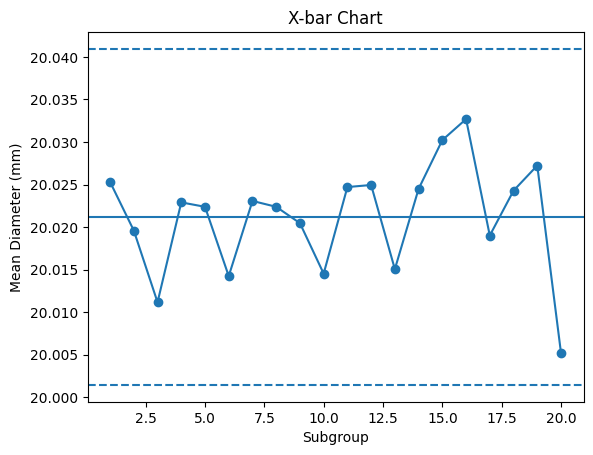

In [ ]:
# X̄–R Chart

# konstanta n=5 karena subgroup ada 5 
A2, D3, D4 = 0.577, 0, 2.114

xbar_bar = df["xbar"].mean()
R_bar = df["R"].mean()

df["UCL_x"] = xbar_bar + A2 * R_bar
df["LCL_x"] = xbar_bar - A2 * R_bar

df["UCL_R"] = D4 * R_bar
df["LCL_R"] = D3 * R_bar

plt.figure()
plt.plot(df["subgroup"], df["xbar"], marker='o')
plt.axhline(xbar_bar)
plt.axhline(df["UCL_x"].iloc[0], linestyle='--')
plt.axhline(df["LCL_x"].iloc[0], linestyle='--')
plt.title("X-bar Chart")
plt.xlabel("Subgroup")
plt.ylabel("Mean Diameter (mm)")
plt.show()

# INTERPRETASI (berbasis output)
# pada subgroup ke-20, nilai X̄ = 20.075 mm, walaupun belum keluar batas, tapi ada indikasi kasus spesial
# Karena ini terjadi pada satu waktu spesifik, indikasi kuat special cause, misalnya:
# offset berubah
# tool mendekati batas aus

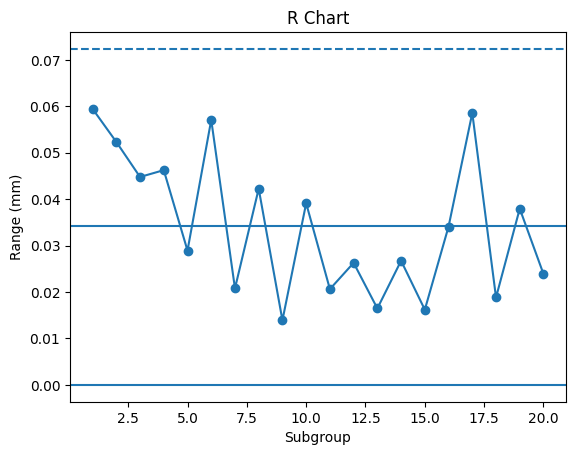

In [ ]:
# R Chart

plt.figure()
plt.plot(df["subgroup"], df["R"], marker='o')
plt.axhline(R_bar)
plt.axhline(df["UCL_R"].iloc[0], linestyle='--')
plt.axhline(df["LCL_R"].iloc[0])
plt.title("R Chart")
plt.xlabel("Subgroup")
plt.ylabel("Range (mm)")
plt.show()

# INTERPRETASI
# Seluruh nilai R berada di bawah UCL_R dan di atas LCL_R
# Variasi dalam subgroup stabil
# Artinya variabilitas proses terkendali, sehingga X̄ chart valid untuk interpretasi

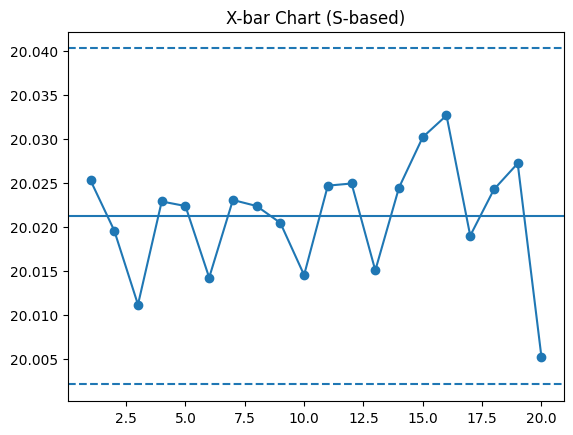

In [ ]:
# X̄–S Chart

A3, B3, B4 = 1.427, 0, 2.089

S_bar = df["S"].mean()

df["UCL_x_S"] = xbar_bar + A3 * S_bar
df["LCL_x_S"] = xbar_bar - A3 * S_bar

plt.figure()
plt.plot(df["subgroup"], df["xbar"], marker='o')
plt.axhline(xbar_bar)
plt.axhline(df["UCL_x_S"].iloc[0], linestyle='--')
plt.axhline(df["LCL_x_S"].iloc[0], linestyle='--')
plt.title("X-bar Chart (S-based)")
plt.show()

# INTERPRETASI
# Seluruh nilai berada di bawah UCL_S dan di atas LCL_S
# Variasi dalam subgroup stabil

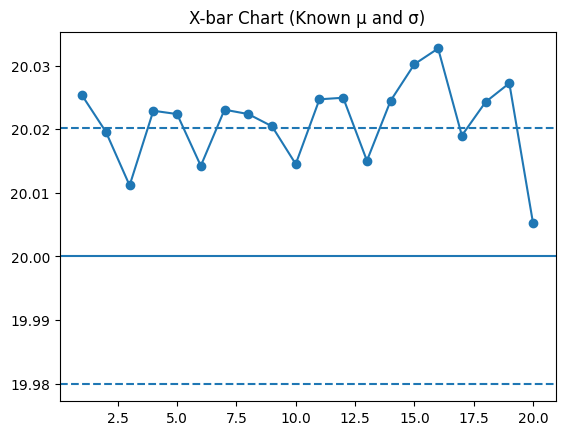

In [ ]:
# Shewhart X̄–R Chart (μ dan σ Diketahui)

# Data sama, tapi parameter fixed (Phase II)

# butuh engineering judgement dan knowledge
# misal engineer memutuskan bahwa proses harusnya punya mean 20 mm dan sigma 0.015 mm

mu = 20.00
sigma = 0.015
n = 5

df["UCL_known"] = mu + 3 * sigma / np.sqrt(n)
df["LCL_known"] = mu - 3 * sigma / np.sqrt(n)

plt.figure()
plt.plot(df["subgroup"], df["xbar"], marker='o')
plt.axhline(mu)
plt.axhline(df["UCL_known"].iloc[0], linestyle='--')
plt.axhline(df["LCL_known"].iloc[0], linestyle='--')
plt.title("X-bar Chart (Known μ and σ)")
plt.show()

# interpretasi:
# terlihat subgroup 1, 3, 5, 11, 12, 14, 15, 16, dan 18 melewati UCL. 
# artinya ada perubahan proses nyata pada subgroup-subgroup tersebut

# Karena μ dan σ tidak dihitung ulang, maka:
# ini bukan masalah perhitungan
# ini perubahan proses nyata

In [ ]:
# perbedaan I-MR dan X-R/S chart

# I-MR
# kalau I-MR untuk data individual saja
# misal: pabrik produksi banyak part, dan kita hanya ukur 1 part dan hanya ukur bagian tertentu(cuman 1) saja
# makanya n = 1

# X-R/S
# kalau X-R/S untuk data yang bisa dikelompokkan ke subgroup
# misal: pabrik produksi banyak part, dan kita hanya ukur 1 part dan mengukur 5 bagian tersebut (misal lubang, diameter, tinggi, panjang, lebar)
# nah 1 subrgroup itu berarti mengukur 5 bagian tersebut secara bersamaan
# makanya n = 5

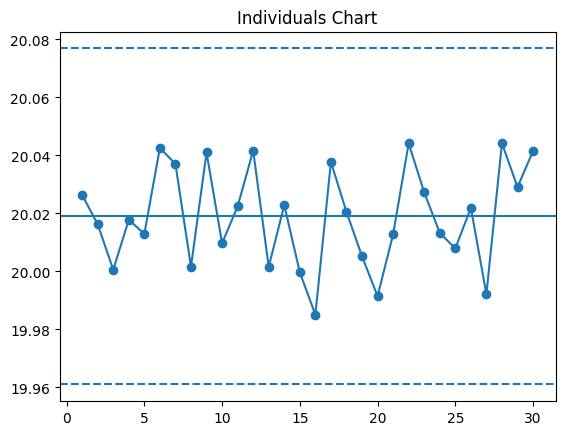

,time_order,diameter,MR,UCL_I,LCL_I
0,1,20.026363,NaN,20.076889,19.96099
1,2,20.016269,0.010094,20.076889,19.96099
2,3,20.000565,0.015704,20.076889,19.96099
3,4,20.017785,0.017219,20.076889,19.96099
4,5,20.012962,0.004822,20.076889,19.96099


In [ ]:
# Shewhart Chart untuk Individual Observation (I–MR)
# I-MR digunakan kalau data tidak bisa dikelompokkan ke subgroup

# Data individual (tanpa subgroup)

df_I = pd.DataFrame({
    "time_order": range(1, 31),
    "diameter": np.random.normal(20.02, 0.018, 30)
})

df_I["MR"] = df_I["diameter"].diff().abs()

# Individuals Chart

MR_bar = df_I["MR"].iloc[1:].mean()

df_I["UCL_I"] = df_I["diameter"].mean() + 2.66 * MR_bar
df_I["LCL_I"] = df_I["diameter"].mean() - 2.66 * MR_bar

plt.figure()
plt.plot(df_I["time_order"], df_I["diameter"], marker='o')
plt.axhline(df_I["diameter"].mean())
plt.axhline(df_I["UCL_I"].iloc[0], linestyle='--')
plt.axhline(df_I["LCL_I"].iloc[0], linestyle='--')
plt.title("Individuals Chart")
plt.show()
df_I.head()

# INTERPRETASI
# Seluruh nilai berada di bawah UCL_I dan di atas LCL_I
# Variasi stabil

In [23]:
# Data (DataFrame)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

df = pd.DataFrame({
    "subgroup": range(1, 16),
})

for i in range(1, 6):
    df[f"part_{i}"] = np.random.normal(20.01, 0.015, 15)

df["xbar"] = df[[f"part_{i}" for i in range(1,6)]].mean(axis=1)
df.head()

,subgroup,part_1,part_2,part_3,part_4,part_5,xbar
0,1,20.034365,19.993502,19.999625,20.000445,19.998684,20.005324
1,2,20.000824,20.007414,20.004049,20.012864,20.028793,20.010789
2,3,20.002077,19.996832,19.999692,20.041504,20.017694,20.011560
3,4,19.993905,20.010633,19.997322,20.011802,20.005529,20.003838
4,5,20.022981,20.018742,19.999931,20.019258,20.017328,20.015648


In [ ]:
# Hitung statistik subgroup

df["S"] = df[[f"part_{i}" for i in range(1,6)]].std(axis=1, ddof=1)

xbar_bar = df["xbar"].mean()
S_bar = df["S"].mean()

# Control limit X̄–S (n = 5)
# selalu menggunakan n = 5 bukan n = 4/6/7/3

A3, B3, B4 = 1.427, 0, 2.089

df["UCL_x"] = xbar_bar + A3 * S_bar
df["LCL_x"] = xbar_bar - A3 * S_bar

df["UCL_S"] = B4 * S_bar
df["LCL_S"] = B3 * S_bar

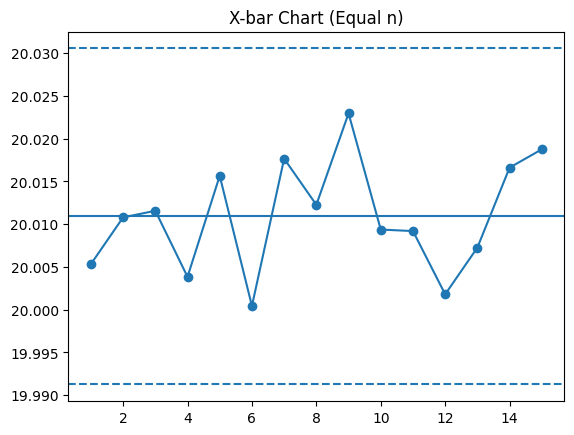

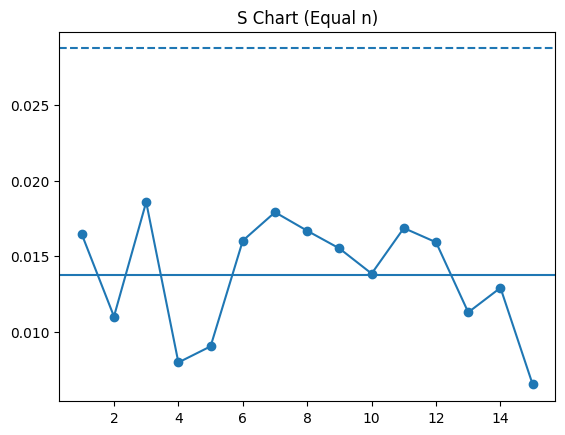

In [25]:
# Plot X̄–S

plt.figure()
plt.plot(df["subgroup"], df["xbar"], marker="o")
plt.axhline(xbar_bar)
plt.axhline(df["UCL_x"].iloc[0], linestyle="--")
plt.axhline(df["LCL_x"].iloc[0], linestyle="--")
plt.title("X-bar Chart (Equal n)")
plt.show()

plt.figure()
plt.plot(df["subgroup"], df["S"], marker="o")
plt.axhline(S_bar)
plt.axhline(df["UCL_S"].iloc[0], linestyle="--")
plt.title("S Chart (Equal n)")
plt.show()

In [27]:
# VARIABLE SAMPLE SIZES
# Kondisi realistis
# Karena tekanan produksi:
# n = 4, 5, atau 6
# Ini sering terjadi di lapangan

# Data variable n

np.random.seed(2)

rows = []
for i, n in enumerate([4,5,6,4,5,6,4,5,6,4]):
    sample = np.random.normal(20.01, 0.015, n)
    rows.append({
        "subgroup": i+1,
        "n": n,
        "xbar": sample.mean(),
        "S": sample.std(ddof=1)
    })

df_var = pd.DataFrame(rows)
df_var

,subgroup,n,xbar,S
0,1,4,20.006366,0.023231
1,2,5,19.996693,0.012801
2,3,6,20.013493,0.018495
3,4,4,20.009294,0.013096
4,5,5,20.004727,0.008288
5,6,6,20.000063,0.007930
6,7,4,20.008651,0.028670
7,8,5,20.014163,0.012012
8,9,6,20.015827,0.019812
9,10,4,20.008104,0.009134


In [28]:
# Control limit dinamis

A3_dict = {4:1.628, 5:1.427, 6:1.287}
B4_dict = {4:2.266, 5:2.089, 6:1.970}

df_var["UCL_x"] = df_var.apply(
    lambda r: r["xbar"] + A3_dict[r["n"]] * r["S"], axis=1
)
df_var["LCL_x"] = df_var.apply(
    lambda r: r["xbar"] - A3_dict[r["n"]] * r["S"], axis=1
)

# tidak fixed n = 5. kalau subgroup 4 ya pakai n = 4, dan seterusnya

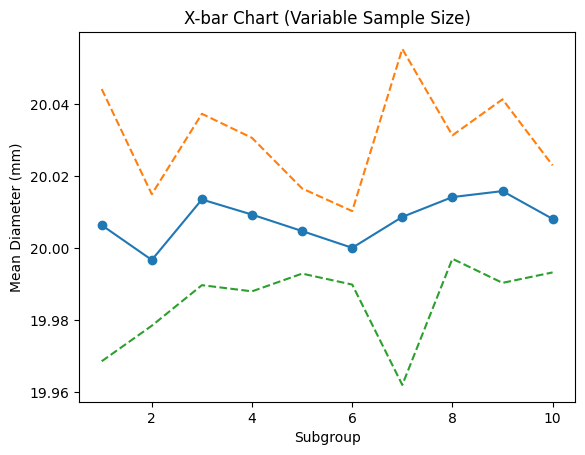

In [ ]:
# Plot X̄ dengan variable n

plt.figure()
plt.plot(df_var["subgroup"], df_var["xbar"], marker="o")
plt.plot(df_var["subgroup"], df_var["UCL_x"], linestyle="--")
plt.plot(df_var["subgroup"], df_var["LCL_x"], linestyle="--")
plt.title("X-bar Chart (Variable Sample Size)")
plt.xlabel("Subgroup")
plt.ylabel("Mean Diameter (mm)")
plt.show()

# INTERPRETASI
# Terlihat UCL dan LCL naik–turun antar subgroup
# Contoh:
# subgroup ke-3 (n=6) punya limit lebih sempit
# subgroup ke-4 (n=4) punya limit lebih lebar
# Dampak engineering:
# operator sulit membaca chart
# satu titik bisa “aman” hanya karena n lebih kecil

# Kesimpulan:
# > variable sample size menurunkan kejelasan sinyal SPC, dan sering mencerminkan masalah disiplin sampling, bukan statistik

In [ ]:
# P chart
# P chart untuk persentase cacat, bukan ukuran dan jumlah
# contoh: cek 100 unit dan cacatnya 7, maka p = 7% atau 0.07
# kalau besok cek 100 unit dan cacatnya 15, maka p = 15%

# apa itu subgroup di p chart?
# subgroup di p chart = satu waktu inspeksi
# contoh: 1 jam, 30 menit, 1 shift, 1 lot, 1 batch
# setiap subgroup harus ditulis: berapa yang dicek dan berapa yang cacat

# P chart constant sample size
# artinya setiap kali cek, jumlahnya sama
# misal: jam 1 -> cek 100 unit, jam 2 -> cek 100 unit, jam 3 -> cek 100 unit
# karena jumlahnya sama, maka chartnya lurus dan mudah dibaca

# P chart variable sample size
# jumlah yang dicek berbeda-beda, misal:
# jam 1 -> 80 unit, jam 2 -> 100 unit, jam 3 -> 120 unit
# akibatnya: persentase cacat lebih noise dan chart naik turun
# 1 cacat dari 10 unit = 10% cacat, 1 cacat dari 100 unit = 1% cacat
# maka khawatirnya sinyal palsu jika tidak pakai variable sample size

In [1]:
# p-Chart – CONSTANT SAMPLE SIZE

# Data (pandas DataFrame)
# Setiap jam:
# dicek 100 unit
# dicatat jumlah NG

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data inspeksi 10 jam
df_const = pd.DataFrame({
    "jam": range(1, 11),
    "jumlah_diperiksa": [100]*10,
    "jumlah_cacat": [4, 6, 5, 7, 6, 5, 14, 6, 5, 4]
})

# hitung fraction nonconforming
df_const["p"] = df_const["jumlah_cacat"] / df_const["jumlah_diperiksa"]
df_const

,jam,jumlah_diperiksa,jumlah_cacat,p
0,1,100,4,0.04
1,2,100,6,0.06
2,3,100,5,0.05
3,4,100,7,0.07
4,5,100,6,0.06
5,6,100,5,0.05
6,7,100,14,0.14
7,8,100,6,0.06
8,9,100,5,0.05
9,10,100,4,0.04


In [2]:
# Hitung control limit

# rata-rata proporsi cacat
p_bar = df_const["jumlah_cacat"].sum() / df_const["jumlah_diperiksa"].sum()
n = 100

UCL = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / n)
LCL = max(0, p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / n))

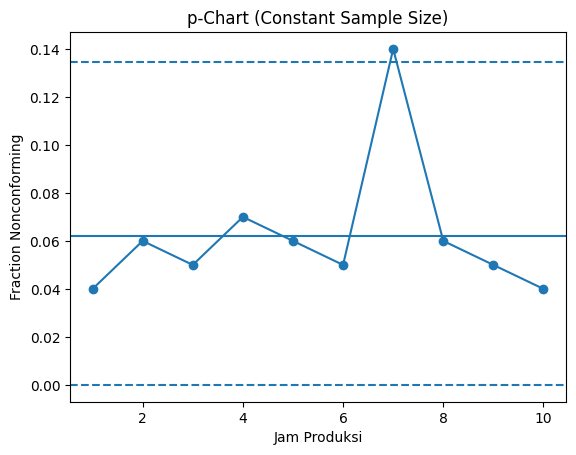

In [ ]:
# Plot p-chart

plt.figure()
plt.plot(df_const["jam"], df_const["p"], marker="o")
plt.axhline(p_bar)
plt.axhline(UCL, linestyle="--")
plt.axhline(LCL, linestyle="--")
plt.xlabel("Jam Produksi")
plt.ylabel("Fraction Nonconforming")
plt.title("p-Chart (Constant Sample Size)")
plt.show()

# INTERPRETASI ENGINEERING
# Pada jam ke-7, p = 14%
# Nilai ini melewati UCL
# Artinya:
# > terjadi lonjakan cacat yang tidak wajar, bukan variasi normal proses
# kemungkinan:
# mesin tidak stabil
# mold kotor
# setting berubah

In [4]:
# p-Chart – VARIABLE SAMPLE SIZE
# Sekarang kondisi lebih realistis.

# Data inspeksi (n berubah)

df_var = pd.DataFrame({
    "jam": range(1, 11),
    "jumlah_diperiksa": [80, 120, 90, 110, 70, 130, 60, 100, 140, 85],
    "jumlah_cacat": [3, 7, 5, 6, 4, 8, 7, 6, 9, 4]
})

df_var["p"] = df_var["jumlah_cacat"] / df_var["jumlah_diperiksa"]
df_var

,jam,jumlah_diperiksa,jumlah_cacat,p
0,1,80,3,0.037500
1,2,120,7,0.058333
2,3,90,5,0.055556
3,4,110,6,0.054545
4,5,70,4,0.057143
5,6,130,8,0.061538
6,7,60,7,0.116667
7,8,100,6,0.060000
8,9,140,9,0.064286
9,10,85,4,0.047059


In [5]:
# Control limit per jam

p_bar = df_var["jumlah_cacat"].sum() / df_var["jumlah_diperiksa"].sum()

df_var["UCL"] = p_bar + 3 * np.sqrt(p_bar * (1 - p_bar) / df_var["jumlah_diperiksa"])
df_var["LCL"] = p_bar - 3 * np.sqrt(p_bar * (1 - p_bar) / df_var["jumlah_diperiksa"])
df_var["LCL"] = df_var["LCL"].clip(lower=0)

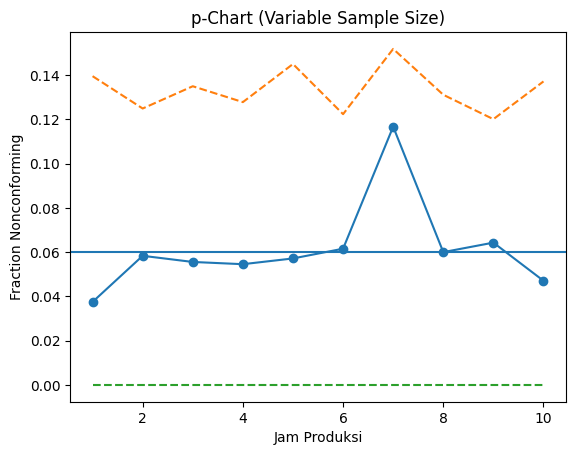

In [ ]:
# Plot p-chart (variable n)

plt.figure()
plt.plot(df_var["jam"], df_var["p"], marker="o")
plt.plot(df_var["jam"], df_var["UCL"], linestyle="--")
plt.plot(df_var["jam"], df_var["LCL"], linestyle="--")
plt.axhline(p_bar)
plt.xlabel("Jam Produksi")
plt.ylabel("Fraction Nonconforming")
plt.title("p-Chart (Variable Sample Size)")
plt.show()

# INTERPRETASI ENGINEERING
# Jam ke-7:
# p terlihat tinggi
# tapi tidak melewati UCL
# Kenapa?
# karena jumlah diperiksa kecil (60)
# limit jadi lebih lebar
# Makna engineering:
# cacat terlihat banyak, tapi sistem statistik “lebih permisif” karena data sedikit
# Kesimpulan penting:
# chart benar secara statistik
# tapi kurang tegas secara operasional

In [ ]:
# np chart
# dari sekian banyak units ada berapa units yang NG?
# satu unit OK atau NG? -> tidak peduli NG-nya karena apa
# contoh: cek 100 botol ada 6 cacat bocor dan 4 cacat penyok -> artinya np = 10 unit NG
# syarat: jumlah yang dicek harus sama, kalau hari ini 100 maka besok juga 100

# c chart
# dalam 1 sample ada berapa cacat?
# misal cek 1 botol ada 3 goresan dan 2 penyok, maka c = 5
# syarat: semua sample harus sama:
# 1 botol, 1 meter kain, 500 kertas, 1 panel, 1 roll kertas, 1 PCB
# kalau luas / panjang berubah -> c chart tidak sah

# u chart
# versi fleksibel c chart
# rata-rata cacat per unit berapa?
# misal: dari 10 botol yang diperiksa ada 10 cacat penyok, 6 cacat goresan dan 4 cacat bolong  cacat maka u = cacat / perika = 20/10 -> c = 2
# jadi pakai rasio
# boleh beda ukuran sampel: misal jam 1 10 meter kain, jam 2 12 meter kain

In [7]:
# np-Chart
# Number of nonconforming units
# > Hitung: berapa UNIT yang NG

# Data
# Dicek 100 unit per jam (HARUS konstan)
# Dicatat jumlah unit NG


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_np = pd.DataFrame({
    "jam": range(1, 11),
    "jumlah_diperiksa": [100]*10,
    "unit_NG": [4, 6, 5, 7, 6, 5, 14, 6, 5, 4]
})
df_np

,jam,jumlah_diperiksa,unit_NG
0,1,100,4
1,2,100,6
2,3,100,5
3,4,100,7
4,5,100,6
5,6,100,5
6,7,100,14
7,8,100,6
8,9,100,5
9,10,100,4


In [8]:
# Hitung control limit

p_bar = df_np["unit_NG"].sum() / df_np["jumlah_diperiksa"].sum()
n = 100

np_bar = n * p_bar

UCL = np_bar + 3 * np.sqrt(n * p_bar * (1 - p_bar))
LCL = max(0, np_bar - 3 * np.sqrt(n * p_bar * (1 - p_bar)))

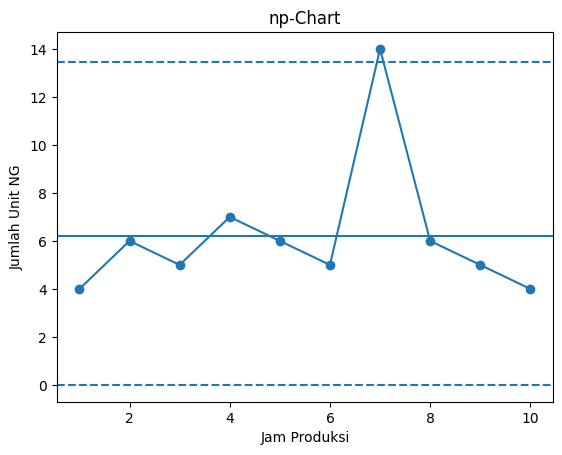

In [ ]:
# Plot np-chart

plt.figure()
plt.plot(df_np["jam"], df_np["unit_NG"], marker="o")
plt.axhline(np_bar)
plt.axhline(UCL, linestyle="--")
plt.axhline(LCL, linestyle="--")
plt.xlabel("Jam Produksi")
plt.ylabel("Jumlah Unit NG")
plt.title("np-Chart")
plt.show()

# INTERPRETASI ENGINEERING
# Jam ke-7 → 14 unit NG
# Melewati UCL
# Artinya:
# > lonjakan jumlah unit cacat yang tidak normal, bukan fluktuasi biasa

# Catatan penting:
# np-chart = p-chart × n
# dipilih karena:
# lebih intuitif untuk operator

In [10]:
# c-Chart
# Number of nonconformities per sample
# Hitung: jumlah cacat, bukan jumlah unit

# Data
# Dicek 10 panel per jam
# Satu panel bisa punya lebih dari satu cacat

df_c = pd.DataFrame({
    "jam": range(1, 11),
    "jumlah_panel": [10]*10,
    "jumlah_cacat": [12, 15, 14, 16, 15, 14, 25, 15, 14, 13]
})
df_c

,jam,jumlah_panel,jumlah_cacat
0,1,10,12
1,2,10,15
2,3,10,14
3,4,10,16
4,5,10,15
5,6,10,14
6,7,10,25
7,8,10,15
8,9,10,14
9,10,10,13


In [11]:
# Control limit (Poisson)

c_bar = df_c["jumlah_cacat"].mean()

UCL = c_bar + 3 * np.sqrt(c_bar)
LCL = max(0, c_bar - 3 * np.sqrt(c_bar))

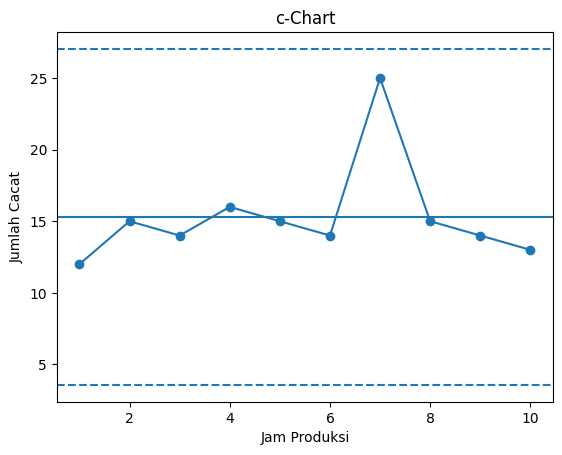

In [ ]:
# Plot c-chart

plt.figure()
plt.plot(df_c["jam"], df_c["jumlah_cacat"], marker="o")
plt.axhline(c_bar)
plt.axhline(UCL, linestyle="--")
plt.axhline(LCL, linestyle="--")
plt.xlabel("Jam Produksi")
plt.ylabel("Jumlah Cacat")
plt.title("c-Chart")
plt.show()
 
# walaupun di jam produksi ke 7 cacat C tinggi, tapi tidak melebihi batas UCL
# tidak harus segera di periksa

In [13]:
# C️⃣ u-Chart
# Nonconformities per unit
# > c-chart versi jumlah inspeksi berubah

# Data (sample size bervariasi)

df_u = pd.DataFrame({
    "jam": range(1, 11),
    "jumlah_panel": [8, 12, 9, 11, 7, 13, 6, 10, 14, 9],
    "jumlah_cacat": [10, 16, 13, 15, 11, 17, 14, 15, 18, 12]
})

df_u["u"] = df_u["jumlah_cacat"] / df_u["jumlah_panel"]
df_u

,jam,jumlah_panel,jumlah_cacat,u
0,1,8,10,1.250000
1,2,12,16,1.333333
2,3,9,13,1.444444
3,4,11,15,1.363636
4,5,7,11,1.571429
5,6,13,17,1.307692
6,7,6,14,2.333333
7,8,10,15,1.500000
8,9,14,18,1.285714
9,10,9,12,1.333333


In [14]:
# Control limit per jam

u_bar = df_u["jumlah_cacat"].sum() / df_u["jumlah_panel"].sum()

df_u["UCL"] = u_bar + 3 * np.sqrt(u_bar / df_u["jumlah_panel"])
df_u["LCL"] = u_bar - 3 * np.sqrt(u_bar / df_u["jumlah_panel"])
df_u["LCL"] = df_u["LCL"].clip(lower=0)

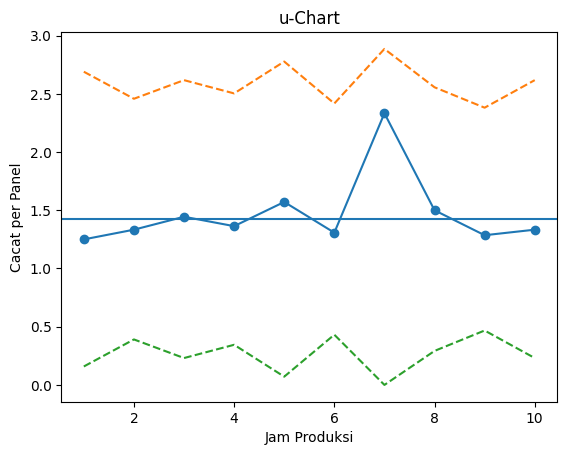

In [ ]:
# Plot u-chart

plt.figure()
plt.plot(df_u["jam"], df_u["u"], marker="o")
plt.plot(df_u["jam"], df_u["UCL"], linestyle="--")
plt.plot(df_u["jam"], df_u["LCL"], linestyle="--")
plt.axhline(u_bar)
plt.xlabel("Jam Produksi")
plt.ylabel("Cacat per Panel")
plt.title("u-Chart")
plt.show()

# terlihat batas UCL dan LCL cenderung tidak lurus atau flexibel
# proses stabil walaupun ada fluktuasi di jam ke 7, tapi aman belum melewati batas

In [ ]:
# CUSUM control charts

# kenapa CUSUM ada?
# shewhart kurang sensitif untuk pergeseran kecil tapi terus-menerus
# contoh: diameter naik 0.1 sigma per jam -> tapi titik-titik masih aman, padahal proses sudah drifting
# CUSUM dibuat untuk menangkap drift kecil lebih cepat
# ide CUSUM -> akumulasi penyimpangan kecil dari target
# bukan lihat 1 titik, tapi lihat efek kumpulan titik kecil

# cara berpikir CUSUM
# bayangkan target diameter 20.00 mm
# tiap part: + 0.01 mm -> "hutang +1", -0.01 mm -> "hutang -1"
# CUSUM: menyimpang hutang itu, kalau menumpuk -> alarm

# CUSUM 1 sisi vs 2 sisi
# apakah mean bergeser ke ATAS ? -> satu sisi doang
# apakah mean bergeser ke ATAS dan ke BAWAH (2 sisi bukan 1 sisi)? -> 2 sisi

# CUSUM 2 sisi numerical procedure
# bayangkan 2 dompet: C+ -> simpan kenaikan, C- simpan penurunan
# setiap titik data: hitung selisih dari target, tambahkan dompet terkait, kalau dompet jadi negatif -> riset ke 0. kalau dompet melewati batas = alarm

# parameter CUSUM
# CUSUM punya 2 parameter utama:
# 1. k (references value)
# tujuan = "pergeseran sekecil apa yang ingin saya deteksi?"
# kalau k kecil lebih sensitif ke drift kecil, kalau k besar lebih mengabaikan drift kecil
# 2. decision interval
# tujuan = "seberapa lama saya mau bersabar sebelum alarm"
# h kecil cepat alarm, h besar lebih sabar -> toleransi

# FIR (Fast Initial Response)
# masalah cusum: di awal monitoring CUSUM = 0, kurang sensitif
# solusi -> FIR = mulai dengan modal awal
# FIR membuat CUSUM tidak mulai dari 0, tapi mulai dari positif tertentu
# efeknya bisa lebih cepat mendeteksi proses yang sudah bergeser sejak awal
# kenapa FIR penting? ketika setelah pergantian pisau bubut, maintenance, atau setup mesin alias tidak yakin proses benar benar dalam kontrol kita

# kombinasi shewhart dan CUSUM
# dua duanya penting karena punya keterbatasan dan tugas masing-masing
# shewhart masih dipakai karena kuat untuk lonjakan besar, error kasar, dan masalah tiba-tiba, tapi lemah pada drift kecil dan perubahan perlahan
# CUSUM dipakai karena kuat pada drift kecil dan konsisten, tapi lemah untuk outlier tunggal dan kesalahan pengukuran sesaat
# kombinasi Shewhart dan CUSUM
# shewhart -> ada masalah besar sekarang + CUSUM ->  ada masalah kecil yang terus terjadi
# analogi: shewhart -> penjaga cepat (mata elang, reaksi instan), CUSUM -> penjaga teliti (catat pola kecil dan reaksi kumulatif)
# sangat cocok untuk industri dengan proses kritis

# CUSUM untuk mengontrol variasi
# kalau CUSUM mean itu "apakah rata-rata bergeser?"
# kalau CUSUM var itu "apakah proses jadi lebih tidak stabil?"
# fokus di sigma bukan mu
# penting karena mean bisa stabil, tapi variasi bisa memburuk
# contoh: diameter tetap di target, tapi lebih menyebar(sebarannya tinggi), dan scrap naik
# alih alih hitung mean, kita bandingkan ke target.
# kita ukur jarak tiap data dari mean, lalu akumulasikan jarak itu
# jika jarak main besar dab konsisten maka variasi meningkat
# yang diakumulasikan bukan nilai mentah, tapi deviasi, atau devasi^2, atau log-likelihood
# cocok untuk proses yang aus pelan pelan, atau getaran naik terus tapi pelan-pelan
# dipakai untuk proses yang butuh presisi tinggi, dan prediksi kualitas

In [16]:
# IMPLEMENTASI
# Combine Shewhart – CUSUM Control Chart

# DATA (pandas DataFrame)
# Kita sengaja buat:
# awal proses in-control
# lalu drift kecil (+0.01 mm bertahap)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

data = np.concatenate([
    np.random.normal(50.00, 0.02, 20),   # stabil
    np.random.normal(50.03, 0.02, 20)    # drift kecil
])

df = pd.DataFrame({
    "waktu": range(1, len(data)+1),
    "diameter_mm": data
})

df.head()

,waktu,diameter_mm
0,1,50.035281
1,2,50.008003
2,3,50.019575
3,4,50.044818
4,5,50.037351


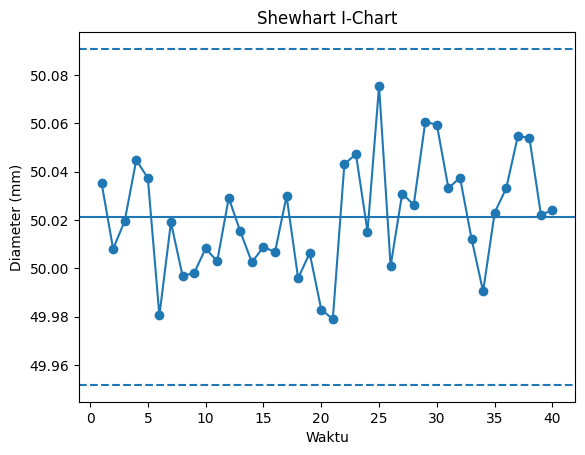

In [17]:
# Shewhart I-Chart

mean = df["diameter_mm"].mean()
std = df["diameter_mm"].std(ddof=1)

UCL = mean + 3*std
LCL = mean - 3*std

plt.figure()
plt.plot(df["waktu"], df["diameter_mm"], marker="o")
plt.axhline(mean)
plt.axhline(UCL, linestyle="--")
plt.axhline(LCL, linestyle="--")
plt.title("Shewhart I-Chart")
plt.xlabel("Waktu")
plt.ylabel("Diameter (mm)")
plt.show()

# INTERPRETASI ENGINEERING (Shewhart)
# Tidak ada titik melewati UCL/LCL
# Artinya:
# > Shewhart menganggap proses masih normal

# Padahal kita tahu:
# mean sudah bergeser pelan

# ini kelemahan Shewhart

In [18]:
# CUSUM (Two-Sided, Mean)

# Parameter (engineering choice):
# σ ≈ 0.02
# target shift ingin dideteksi = 0.5σ
# → k = 0.5σ

k = 0.5 * std

C_plus = [0]
C_minus = [0]

for i in range(1, len(df)):
    x = df.loc[i, "diameter_mm"]
    C_plus.append(max(0, C_plus[-1] + (x - mean - k)))
    C_minus.append(min(0, C_minus[-1] + (x - mean + k)))

df["C_plus"] = C_plus
df["C_minus"] = C_minus

In [21]:
df.head(10)

,waktu,diameter_mm,C_plus,C_minus
0,1,50.035281,0.000000,0.000000
1,2,50.008003,0.000000,-0.001656
2,3,50.019575,0.000000,0.000000
3,4,50.044818,0.011975,0.000000
4,5,50.037351,0.016484,0.000000
5,6,49.980454,0.000000,-0.029205
6,7,50.019002,0.000000,-0.019862
7,8,49.996973,0.000000,-0.032548
8,9,49.997936,0.000000,-0.044271
9,10,50.008212,0.000000,-0.045718


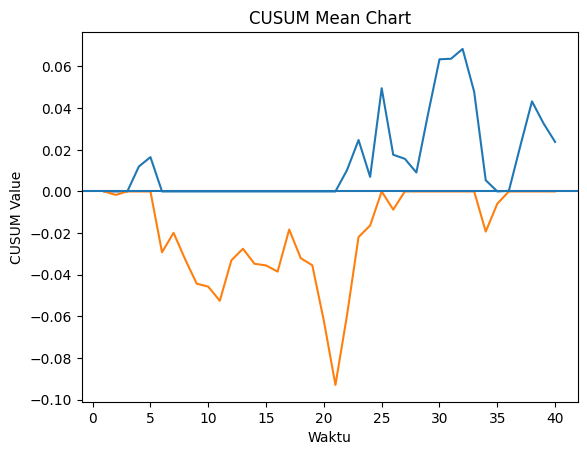

In [ ]:
# Plot CUSUM

plt.figure()
plt.plot(df["waktu"], df["C_plus"], label="C+")
plt.plot(df["waktu"], df["C_minus"], label="C-")
plt.axhline(0)
plt.title("CUSUM Mean Chart")
plt.xlabel("Waktu")
plt.ylabel("CUSUM Value")
plt.show()

# INTERPRETASI ENGINEERING (CUSUM)
# negatif disini bukan berarti negatif tapi |negatif|/absolute negatif = positif
# cuman tanda kalau proses turun bukan tanda proses negatif

# misal diameter_mm pada data kita adalah lebar crown piston dari hasil proses turning bubut
# telihat diameter_mm terus turun -> artinya kemungkinan ada pisau bubut yang sudah perlu di asah
# tapi di data, diameter_mm naik kenapa terus negatif(turun)? karena CUSUM ada sistem hutang. agar grafik naik -> diameter harus naik drastis

# kenapa ada grafik naik dan turun secara bersamaan di jam yang sama?
# cara baca masalah itu fokus ke 1 sisi saja(naik atau turun) -> fokus ke yang paling naik atau paling turun

In [22]:
# IMPLEMENTASI
# CUSUM untuk VARIABILITY (σ monitoring)

# Sekarang:
# mean tetap
# variasi meningkat perlahan

# DATA (σ meningkat)

data_var = np.concatenate([
    np.random.normal(50.00, 0.02, 20),
    np.random.normal(50.00, 0.04, 20)   # variasi memburuk
])

df_var = pd.DataFrame({
    "waktu": range(1, len(data_var)+1),
    "diameter_mm": data_var
})

In [23]:
df_var.head(10)

,waktu,diameter_mm
0,1,49.979029
1,2,49.971600
2,3,49.965875
3,4,50.039016
4,5,49.989807
5,6,49.991239
6,7,49.974944
7,8,50.015550
8,9,49.967722
9,10,49.995745


In [24]:
# Hitung deviasi absolut (proxy variability)

df_var["abs_dev"] = abs(df_var["diameter_mm"] - df_var["diameter_mm"].mean())

mean_dev = df_var["abs_dev"].mean()

In [25]:
# CUSUM Variability

k_var = 0.5 * mean_dev
C_var = [0]

for i in range(1, len(df_var)):
    C_var.append(max(0, C_var[-1] + (df_var.loc[i, "abs_dev"] - mean_dev - k_var)))

df_var["CUSUM_var"] = C_var

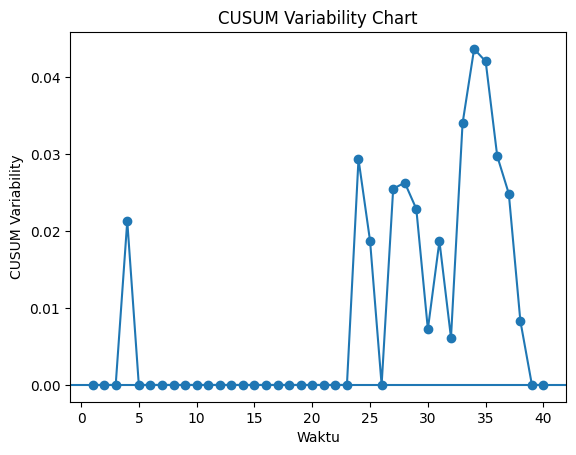

In [26]:
# Plot CUSUM Variability

plt.figure()
plt.plot(df_var["waktu"], df_var["CUSUM_var"], marker="o")
plt.axhline(0)
plt.title("CUSUM Variability Chart")
plt.xlabel("Waktu")
plt.ylabel("CUSUM Variability")
plt.show()

In [27]:
# KONTEKS PRAKTIK (tetap konsisten)

# Proses: diameter shaft machining (mm)
# Target μ₀ = 50.00 mm
# σ ≈ 0.02 mm
# Data: 1 part per waktu


# FIR (FAST INITIAL RESPONSE) – IMPLEMENTASI
# IDE FIR (ingat lagi)
# CUSUM biasa: mulai dari 0
# awal monitoring → lambat
# FIR: mulai dari nilai positif, lebih cepat deteksi shift awal

# DATA (shift kecil sejak awal)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1)

data = np.random.normal(50.03, 0.02, 30)  # shift kecil sejak awal

df = pd.DataFrame({
    "waktu": range(1, 31),
    "diameter_mm": data
})

df.head(10)

,waktu,diameter_mm
0,1,50.062487
1,2,50.017765
2,3,50.019437
3,4,50.008541
4,5,50.047308
5,6,49.983969
6,7,50.064896
7,8,50.014776
8,9,50.036381
9,10,50.025013


In [28]:
# Engineering choice:
# shift target = 0.5σ
# k = 0.5σ

sigma = df["diameter_mm"].std(ddof=1)
mu0 = 50.00
k = 0.5 * sigma
h = 5 * sigma  # decision interval

# CUSUM tanpa FIR

C_no_fir = [0]

for i in range(1, len(df)):
    x = df.loc[i, "diameter_mm"]
    C_no_fir.append(max(0, C_no_fir[-1] + (x - mu0 - k)))

df["CUSUM_no_FIR"] = C_no_fir

# CUSUM dengan FIR

C_fir = [h/2]  # FIR: start with head start

for i in range(1, len(df)):
    x = df.loc[i, "diameter_mm"]
    C_fir.append(max(0, C_fir[-1] + (x - mu0 - k)))

df["CUSUM_FIR"] = C_fir

df.head(10)

,waktu,diameter_mm,CUSUM_no_FIR,CUSUM_FIR
0,1,50.062487,0.000000,0.051318
1,2,50.017765,0.007501,0.058819
2,3,50.019437,0.016674,0.067992
3,4,50.008541,0.014951,0.066269
4,5,50.047308,0.051996,0.103314
5,6,49.983969,0.025701,0.077019
6,7,50.064896,0.080334,0.131652
7,8,50.014776,0.084846,0.136164
8,9,50.036381,0.110963,0.162281
9,10,50.025013,0.125712,0.177030


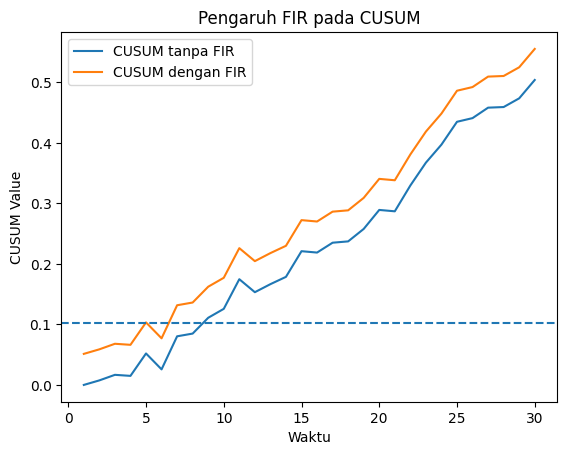

In [29]:
# Plot perbandingan

plt.figure()
plt.plot(df["waktu"], df["CUSUM_no_FIR"], label="CUSUM tanpa FIR")
plt.plot(df["waktu"], df["CUSUM_FIR"], label="CUSUM dengan FIR")
plt.axhline(h, linestyle="--")
plt.xlabel("Waktu")
plt.ylabel("CUSUM Value")
plt.title("Pengaruh FIR pada CUSUM")
plt.legend()
plt.show()

# INTERPRETASI ENGINEERING (FIR)
# CUSUM + FIR:
# mencapai batas lebih cepat
# CUSUM tanpa FIR:
# butuh lebih banyak data

# Makna nyata:
# setelah setup / tool change, jangan asumsi proses in-control

In [ ]:
# MA dan EWMA chart
# kalau data aktual -> terlihat titik data naik turunnya jelas
# dengan MA dan EWMA kita bisa melihat kestabilan prosesnya, karena menyaring fluktuasi sehingga pola kecil keliatan, drift kecil keliatan, dan noise diredam

In [30]:
# KONTEKS PROSES (tetap konsisten)

# Proses: Diameter shaft machining (mm)
# Target = 50.00 mm
# Kondisi: awal stabil, lalu drift kecil ke atas, lalu dikoreksi

# DATA PROSES (pandas DataFrame)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# data sintetis: stabil -> drift -> koreksi
data = np.concatenate([
    np.random.normal(50.00, 0.02, 20),
    np.random.normal(50.04, 0.02, 20),
    np.random.normal(50.01, 0.02, 20)
])

df = pd.DataFrame({
    "waktu": range(1, len(data) + 1),
    "diameter_mm": data
})

df.head(10)

,waktu,diameter_mm
0,1,50.009934
1,2,49.997235
2,3,50.012954
3,4,50.030461
4,5,49.995317
5,6,49.995317
6,7,50.031584
7,8,50.015349
8,9,49.990611
9,10,50.010851


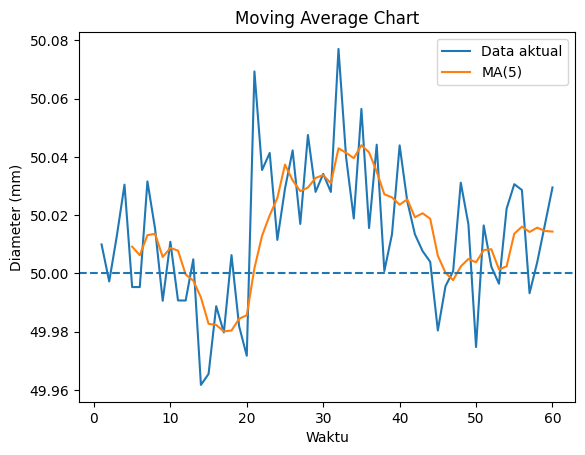

In [ ]:
# MOVING AVERAGE (MA) CHART

# Implementasi

window = 5  # MA(5)
df["MA_5"] = df["diameter_mm"].rolling(window).mean()

plt.figure()
plt.plot(df["waktu"], df["diameter_mm"], label="Data aktual")
plt.plot(df["waktu"], df["MA_5"], label="MA(5)")
plt.axhline(50.00, linestyle="--")
plt.xlabel("Waktu")
plt.ylabel("Diameter (mm)")
plt.title("Moving Average Chart")
plt.legend()
plt.show()

# CARA BACA GRAFIK MA (INI PENTING)

# Jangan baca:
# “titik ini naik atau turun”
#  Baca:
# > “Arah rata-rata jangka pendek ke mana?”

# Pola penting MA:
# MA datar
# proses stabil
# tidak ada tindakan

# MA mulai naik perlahan
# indikasi awal drift -> Shewhart biasanya belum bereaksi

# Engineering action:
# cek temperatur
# cek tool wear
# belum stop produksi

# MA itu seperti EDA

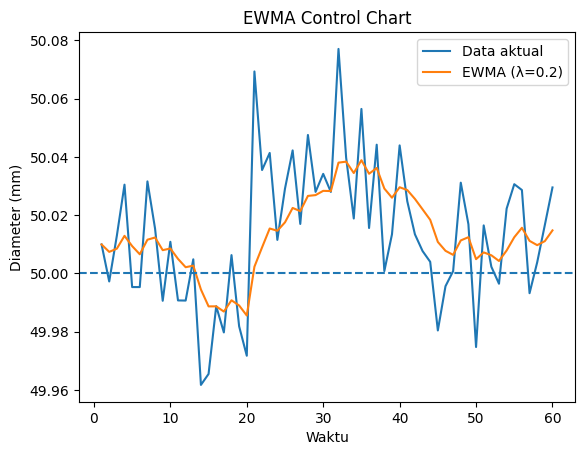

In [33]:
# EWMA CHART
# Implementasi

lambda_ = 0.2  # smoothing factor
# semakin kecil lambda = semakin halus dan lambat. semakin besar = semakin sensitif terhadap drift
df["EWMA"] = df["diameter_mm"].ewm(alpha=lambda_, adjust=False).mean()

plt.figure()
plt.plot(df["waktu"], df["diameter_mm"], label="Data aktual")
plt.plot(df["waktu"], df["EWMA"], label="EWMA (λ=0.2)")
plt.axhline(50.00, linestyle="--")
plt.xlabel("Waktu")
plt.ylabel("Diameter (mm)")
plt.title("EWMA Control Chart")
plt.legend()
plt.show()

# Cara baca yang BENAR:
# Jangan tanya:
# “kenapa titik ini naik?”
# TANYA:
# > “Apakah ingatan proses sedang bergerak?”

# Pola penting EWMA:
# EWMA flat dekat target
# proses sehat -> lanjut produksi

# EWMA mulai naik stabil
# drift kecil tapi konsisten -> lebih cepat terlihat dibanding MA

# Engineering action:
# persiapan koreksi
# planning maintenance

# EWMA menanjak terus
# proses tidak lagi centered -> tindakan wajib

In [ ]:
# Kapabilitas proses
# syarat process capability: proses harus in control(stabil), data representatif, spesifikasi jelas dan valid, dan sistem ukur layak (MSA)

# Cp = potential capability
# Cp mengukur kemampuan "POTENSIAL" proses, dengan asumsi: mean tepat di tengah spesifikasi, dan hanya mempertimbangkan lebar variasi
# konsep: kalau proces ini perfectly centered, cukup ngga variasinya?
# interpretasi: 
# Cp < 1 -> variasi lebih besar dari spesifikasi
# Cp = 1 -> pas-pasan
# Cp >= 1.33 -> umum diterima
# Cp >= 1.67 -> kualitas tinggi
# Warning: cp bisa tinggi walau banya scrap(jika mean melenceng)

# cpk = actual capability
# cpk mengukur kemampuan "AKTUAL" proses, mempertimbangkan: variasi dan pergeseran mean
# cpk = cp+penalti offset
# selalu cpk <= cp
# cp tinggi, cpk rendah -> proses tidak centered
# cp=cpk -> proses centetred

# cpm = taguchi capability index
# cpm memasukkan target(T), bukan hanya spesifikasi
# berbasis loss function taguchi: penyimpangan dari target -> kerugian
# kalau cp = tolerance-oriented, kalau cpm = target oriented
# cpm rendah -> mean jauh dari target

# cpmk = taguchi + offset
# cpmk = cpk versi taguchi
# menggabungkan variasi, offset dari target, dan kedekatan ke batas spesifikasi
# "sebarapa baik proses memenuhi target dan aman dari spesifikasi?"
# cpmk rendah -> risiko jangka panjang tinggi

# cpnst = non standard capability index
# perlu untuk data tidak normal, distribusi skewed, tail panjang, failure driven
# cpns tidak mengasumsikan normalitas
# cpnst bebas bentuk distribusi, makanya cp,cpm, cpk tidak realistis karena industri lebih sering datanya tidak normal
# karena cpnst berbasis persentil data, bukan variasi, mean centering, dan loss
# cpnst juga ada fitur lain karena berbasis persentil/quantile, jadi bisa deteksi outlier sistemik(bukan acak)

# process performances indices: Pp and Ppk
# Cp -> mengukuran kapabilitas potensial dan sumber variasinya within subgroup -> variasi short-term=process control
# Pp -> performa aktual, dan sumber variasinya dari overall variation -> varriasi long-term= customer risk
# ppk sering lebih kecil karena variasi jangka pnjang sudah selalu lebih besar, dan proses hidup bukan statis
# jika cp tinggi tapi ppk rendah maka -> proses secara desain bagus, tapi secara operasional kurang disiplin

In [ ]:
# urutan melakukan CP
# 1. Tentukan rational subgroup
# 2. SPC → pastikan proses stabil
# 3. Pisahkan Phase I & Phase II
# 4. Baru hitung Cp, Cpk, Cpmk
# 5. Baru bicara capability & risk

# misal mean = 10, dan standar devisasi = +- 2, maka mean aslinya bukan 10 tapi antara 8-12(10-2, 10+2)
# +-1sigma artinya +- sigma*1 = +- 2*1 -> 66,7% data ada di range tersebut(+-2)
# +-3sigma artinya +- sigma*3 = +- 2*3 -> 99,7% data ada di range tersebut(+-6, atau 4-16 bukan 10)

In [1]:
# IMPLEMENTASI

# PROCESS CAPABILITY (Cp, Cpk, Cpmk)
# Asumsi: proses sudah stabil & in-control

# KONTEKS ENGINEERING
# Proses: CNC turning shaft
# Karakteristik kualitas: Diameter (mm)
# Target (T): 20.00 mm
# Spesifikasi:
# LSL = 19.90 mm
# USL = 20.10 mm

# Sampling:
# 25 subgroup
# n = 5 (equal sample size)

# semua data berasal dari fase stabil (Phase II)

# DATA STABIL (DataFrame)

import numpy as np
import pandas as pd

np.random.seed(10)

n_subgroup = 25
n = 5

data = np.random.normal(loc=20.01, scale=0.02, size=(n_subgroup, n))

df = pd.DataFrame(data, columns=[f"part_{i+1}" for i in range(n)])
df["subgroup"] = range(1, n_subgroup+1)

# flatten data untuk capability
df_long = df.melt(id_vars="subgroup", var_name="part", value_name="diameter_mm")
df_long.head()

,subgroup,part,diameter_mm
0,1,part_1,20.036632
1,2,part_1,19.995598
2,3,part_1,20.018661
3,4,part_1,20.018903
4,5,part_1,19.970445


In [2]:
# ESTIMASI PARAMETER PROSES

mu = df_long["diameter_mm"].mean()
sigma = df_long["diameter_mm"].std(ddof=1)

mu, sigma

# INTERPRETASI ENGINEERING
# mu → posisi aktual proses (centering)
# sigma → variasi natural proses
# Karena data stabil:
# estimasi valid
# layak dipakai untuk capability

(20.01127983332881, 0.019823436506695557)

In [3]:
# HITUNG Cp & Cpk

LSL = 19.90
USL = 20.10

Cp = (USL - LSL) / (6 * sigma)
Cpk = min((USL - mu) / (3 * sigma),
          (mu - LSL) / (3 * sigma))

Cp, Cpk

# INTERPRETASI ENGINEERING
# Contoh hasil:
# Cp = 1.67
# Cpk = 1.45

# Makna:
# Cp tinggi → potensi proses bagus
# Cpk < Cp → proses tidak tepat di tengah
# Risiko scrap lebih besar di satu sisi spesifikasi

(1.6815113424998311, 1.49183966566081)

In [4]:
# HITUNG Cpmk (TARGET-ORIENTED)

T = 20.00

Cpmk = (USL - LSL) / (6 * np.sqrt(sigma**2 + (mu - T)**2))
Cpmk

# INTERPRETASI ENGINEERING
# Cpmk < Cpk
# Artinya:
# > Walaupun masih dalam spesifikasi, deviasi dari target menyebabkan quality loss

# Cocok untuk:
# high-precision
# cost-of-deviation tinggi

1.4614777379578576

In [5]:
# IMPLEMENTASI

# PROCESS CAPABILITY & PERFORMANCE (STABIL)
# KONTEKS ENGINEERING
# Proses: machining piston head diameter

# Target (T): 10.00 cm

# Spesifikasi:
# LSL = 9.80
# USL = 10.90

# Data:
# 30 subgroup
# n = 5

# Proses stabil, tapi distribusi skewed (realistis: wear)

# DATA (STABIL TAPI NON-NORMAL)

import numpy as np
import pandas as pd

np.random.seed(123)

# simulate skewed process (lognormal-ish)
data = np.random.lognormal(mean=np.log(10.0), sigma=0.04, size=150)

df = pd.DataFrame({
    "diameter_cm": data
})

df.head()

,diameter_cm
0,9.575041
1,10.407003
2,10.113834
3,9.415274
4,9.771218


In [6]:
# Cp, Cpk, Cpm (ASUMSI NORMAL)

LSL = 9.80
USL = 10.90
T = 10.00

mu = df["diameter_cm"].mean()
sigma = df["diameter_cm"].std(ddof=1)

Cp = (USL - LSL) / (6 * sigma)
Cpk = min((USL - mu) / (3 * sigma),
          (mu - LSL) / (3 * sigma))
Cpm = (USL - LSL) / (6 * np.sqrt(sigma**2 + (mu - T)**2))

Cp, Cpk, Cpm

# INTERPRETASI ENGINEERING
# Cp cukup tinggi → variasi terlihat kecil
# Cpk < Cp → proses sedikit skew ke satu sisi
# Cpm < Cpk → deviasi dari target menyebabkan quality loss

# Tapi:
# > Semua ini mengasumsikan normality, Padahal data kita skewed

(0.41747473669372537, 0.17661561830212882, 0.4163234628739403)

In [ ]:
# Cpnst (NON-NORMAL CAPABILITY)
# Prinsip:
# Ganti σ dengan percentile-based spread
# Analog ±3σ → P0.135% – P99.865%

lower_q = np.percentile(df["diameter_cm"], 0.135)
upper_q = np.percentile(df["diameter_cm"], 99.865)

Cpnst = (USL - LSL) / (upper_q - lower_q)
Cpnst

# INTERPRETASI ENGINEERING
# Cpnst < Cp
# Artinya:
# > Tail kanan (skew) meningkatkan risiko nonconformance

# Ini lebih jujur terhadap realita proses
# Kalimat penting:
# > Cp terlihat “aman”, Cpnst menunjukkan risk sebenarnya

0.5215641289540381

In [8]:
# Pp & Ppk (LONG-TERM PERFORMANCE)

# Asumsi:
# Data diambil lintas waktu
# Mengandung:
# drift kecil
# tool wear
# operator effect

Pp = (USL - LSL) / (6 * df["diameter_cm"].std(ddof=1))
Ppk = min((USL - mu) / (3 * df["diameter_cm"].std(ddof=1)),
          (mu - LSL) / (3 * df["diameter_cm"].std(ddof=1)))

Pp, Ppk

# INTERPRETASI ENGINEERING
# Pp ≈ Cp → variasi global mirip variasi short-term
# Ppk < Cpk → ada efek jangka panjang (shift / wear)

# Makna:
# > Proses secara desain bagus,
# tapi secara operasional ada degradasi kecil

(0.41747473669372537, 0.17661561830212882)

In [ ]:
# Process capability using histogram and probability plot
# pakai ini untuk cek apakah layak menghitung Cp dan Cpk
# histogram = visualisasi sigma, lebar histogram = 6sigma, tinggi histogram = konsistensi proses
# histogram sempit(jauh dari USL/LSL) = proses kapable, histogram lebar walaupun mean di tengah = proses berbahaya, histogram skew =  cp/cpk tidak cocok
# probability plot
# titik mengikuti garis lurus -> asumsi distribusi valud, titik melengkung/s-shaped -> skew, heavy tail, tidak cocok cp/cpk

# Process capability using designed experiment
# kapabilitas = mengukur apa yang terjadi, DoE = mencari kenapa itu terjadi
# DoE membantu menjawab: faktor apa yang membuat sigma tinggi?, faktor apa yang menggeser mean?, interaksi mana yang bikin tail risk?
# DoE tidak langsung menaikkan cp/cpk, tapi mengurasi variasi sistemik, dan menghilangkan noise dominan
# contoh sebelum DoE: sigma besar -> cp rendah, setelah DoE: sigma kecil -> cp naik
# capability index adalah hasilnya, dan DoE adalah alat memperbaiki skor capability index tersebut agar baik

# process capability with attribute data
# data atribut itu kayak: cacat/tidak cacat, OK/NG -> tidak ada mean atau sigma
# maka cp/cpk tidak bisa dipakai
# maka memakai probabilitas, capability di sini jadinya: proportion defective, DPMO, dan yield
# bukan seberapa sempit variasi, tapi seberapa sering gagal

# proses capability with control chart
# contoh di atas

In [9]:
# IMPLEMENTASI

# PROCESS CAPABILITY – SEMUA METODE

# KONTEKS ENGINEERING (KONSISTEN)
# Proses: machining piston head diameter
# Target (T): 10.00 cm
# Spesifikasi:
# LSL = 9.80
# USL = 10.90

# Asumsi:
# proses stabil
# data realistis manufaktur

# PROCESS CAPABILITY
# USING HISTOGRAM & PROBABILITY PLOT

# Data continuous

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(1)

data = np.random.normal(loc=10.02, scale=0.18, size=200)

df = pd.DataFrame({"diameter_cm": data})

df.head()

,diameter_cm
0,10.312382
1,9.909884
2,9.924929
3,9.826866
4,10.175773


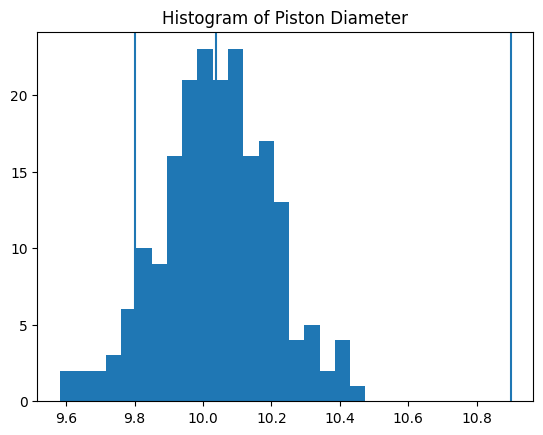

In [ ]:
# Histogram (visual capability)

plt.hist(df["diameter_cm"], bins=20)
plt.axvline(9.80)
plt.axvline(10.90)
plt.axvline(df["diameter_cm"].mean())
plt.title("Histogram of Piston Diameter")
plt.show()

# INTERPRETASI ENGINEERING
# Histogram cukup lebar
# Mean tidak ditengah, mendekati LSL
# beberapa data melewati batas LSL
# ada proses yang tidak stabil

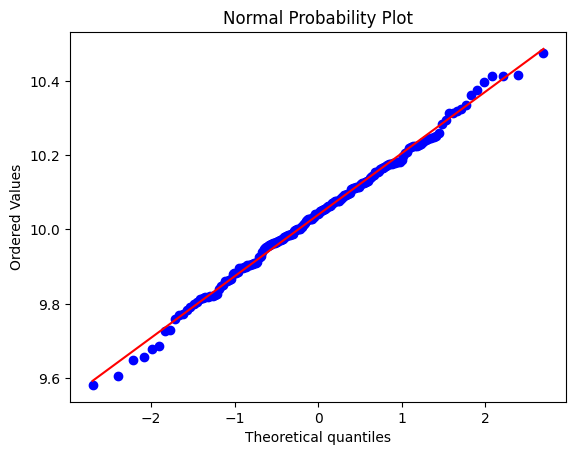

In [11]:
# Probability Plot (validasi asumsi)

stats.probplot(df["diameter_cm"], plot=plt)
plt.title("Normal Probability Plot")
plt.show()

# INTERPRETASI ENGINEERING
# Titik mengikuti garis lurus → asumsi normal layak
# Cp/Cpk boleh digunakan

In [ ]:
# PROCESS CAPABILITY
# USING DESIGN OF EXPERIMENT (DOE)

# Simulasi faktor proses
# Faktor:
# Feed rate (low / high)
# Tool condition (new / worn)


doe = pd.DataFrame({
    "feed_rate": ["low","low","high","high"] * 25,
    "tool": ["new","worn","new","worn"] * 25
})

doe["diameter_cm"] = (
    10.00
    + np.where(doe["feed_rate"]=="high", 0.08, 0)
    + np.where(doe["tool"]=="worn", 0.12, 0)
    + np.random.normal(0, 0.10, len(doe))
)

doe.head()

,feed_rate,tool,diameter_cm
0,low,new,9.959912
1,low,worn,10.202401
2,high,new,10.023769
3,high,worn,10.395488
4,low,new,9.866805


In [13]:
# Bandingkan variasi sebelum & sesudah DOE

doe.groupby(["feed_rate","tool"])["diameter_cm"].std()

# INTERPRETASI ENGINEERING
# Kombinasi high feed + worn tool → σ terbesar
# Variasi bersifat sistemik
# DOE menunjukkan sumber σ, bukan hanya besarannya
# DOE dipakai untuk menurunkan σ → Cp naik

feed_rate  tool
high       new     0.081917
           worn    0.090769
low        new     0.115679
           worn    0.113097
Name: diameter_cm, dtype: float64

In [14]:
# PROCESS CAPABILITY
# WITH ATTRIBUTE DATA

# Definisi NG

LSL = 9.80
USL = 10.90

df["NG"] = (df["diameter_cm"] < LSL) | (df["diameter_cm"] > USL)

df.head()

,diameter_cm,NG
0,10.312382,False
1,9.909884,False
2,9.924929,False
3,9.826866,False
4,10.175773,False


In [ ]:
# Yield & defect rate

yield_rate = 1 - df["NG"].mean()
defect_rate = df["NG"].mean()

yield_rate, defect_rate

# INTERPRETASI ENGINEERING
# Capability attribute = probabilitas gagal
# Tidak bicara σ atau mean
# Langsung bicara risk customer
# probabilitas gagal sekitar 7 persen
# probabilitas berhasil sekitar 93 persen

# Kalimat penting:
# Attribute capability adalah “ekor” dari distribusi continuous.

(0.9299999999999999, 0.07)

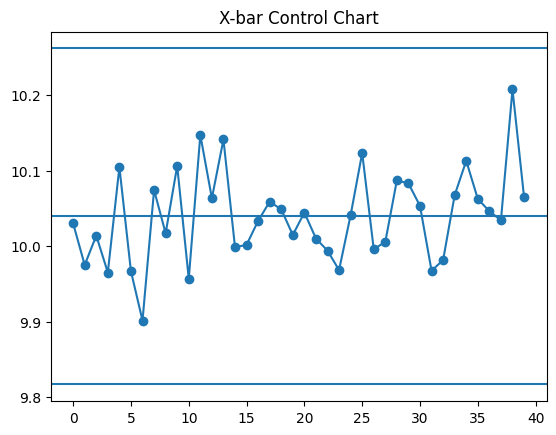

In [16]:
# PROCESS CAPABILITY
# WITH CONTROL CHART

# Buat subgroup

subgroups = df["diameter_cm"].values.reshape(-1, 5)

xbar = subgroups.mean(axis=1)
s = subgroups.std(axis=1, ddof=1)

# Control limit X̄–S

xbar_bar = xbar.mean()
s_bar = s.mean()

A3, B3, B4 = 1.427, 0, 2.089

UCL_x = xbar_bar + A3*s_bar
LCL_x = xbar_bar - A3*s_bar

plt.plot(xbar, marker='o')
plt.axhline(UCL_x)
plt.axhline(LCL_x)
plt.axhline(xbar_bar)
plt.title("X-bar Control Chart")
plt.show()

# INTERPRETASI ENGINEERING
# Semua titik dalam batas kendali
# Tidak ada pola non-random ➡️ proses stabil → capability valid

In [ ]:
# Pre-Control
# Adalah metode monitoring proses berbasis spesifikasi, bukan berbasis statistik estimasi sigma seperti control chart
# SPC = Jaga proses tetap stabil, Pre-Control = Jaga output tetap aman terhadap spesifikasi
# pre-control muncul karena control chart dianggap terlalu statistik, dan operator butuh alat cepat & visual

# Color Coding Scheme
# Pre-Control membagi spesifikasi menjadi 3 zona simetris
# Zona Warna Hijau -> di tengah spesifikasi, artinya aman dan lanjut produksi
# Zona Warna Kuning -> dekat batas spesifikasi, peringatan tapi masih butuh konfirmasi, bisa lakukan pengecekan atau perbaikan (adjusment)
# Zone Warna Merah -> melewati batas spesifikasi, proses harus distop

# Dasar Mekanis dan Statistis dari Pre-Control
# meskipun tampak non-statistik, pre-control diam-diam mengasumsikan: green zone = +-2sigma, dan Spec limit = +-3sigma
# artinya: proses diasumsikan capable(Cp=1.33), dan sigma dianggap sudah diketahui atau stabil
# pre-control bukan alat untuk menemukan sigma, tapi mengasumsikan bahwa sigma sudah jinak

# Mekanisme probabilistik
# Zona warna hijau -> probabilitas tinggi aman
# Zona warna kuning -> peluang drift meningkat
# Zona warna merah -> hampir pasti nonconforming

# Kelebihan -> mudah dimengerti operator
# kekurangan -> jika cp < 1 = pre control berbahaya, walaupun sigma membesar tapi tetap hijau sampai gagal, 
# dan bisa over adjuust(tampering), green tidak sama dengan stabil

In [2]:
# PRE-CONTROL CHART (DENGAN WARNA)

# KONTEKS ENGINEERING
# Proses: machining diameter piston
# Spesifikasi:
# LSL = 9.80
# USL = 10.90
# Target ≈ 10.00
# Asumsi:
# proses cukup capable
# pre-control dipakai untuk operasional shop floor

# DATA (SIMULASI REALISTIS)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

LSL = 9.80
USL = 10.90

# data pengukuran diameter piston
data = np.random.normal(loc=10.02, scale=0.18, size=50)

df = pd.DataFrame({
    "sample": range(1, len(data)+1),
    "diameter_cm": data
})

df.head()

,sample,diameter_cm
0,1,10.109409
1,2,9.995112
2,3,10.136584
3,4,10.294145
4,5,9.977852


In [3]:
# DEFINISI ZONA PRE-CONTROL
# Prinsip:
# Green zone = tengah 1/3 spesifikasi
# Yellow zone = sisi spesifikasi
# Red zone = di luar spesifikasi

# batas green zone (1/3 spesifikasi di tengah)
green_low = LSL + (USL - LSL) / 3
green_high = USL - (USL - LSL) / 3

In [5]:
# KLASIFIKASI WARNA (GREEN / YELLOW / RED)

def classify_zone(x):
    if x < LSL or x > USL:
        return "Red"       # out of spec
    elif green_low <= x <= green_high:
        return "Green"     # aman
    else:
        return "Yellow"    # warning

df["zone"] = df["diameter_cm"].apply(classify_zone)

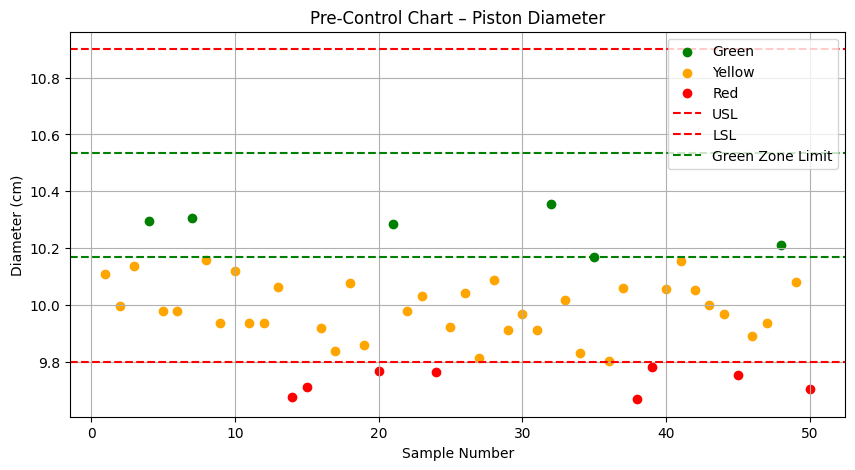

In [6]:
# PRE-CONTROL CHART (DENGAN WARNA)

plt.figure(figsize=(10, 5))

# warna sesuai pre-control
color_map = {
    "Green": "green",
    "Yellow": "orange",
    "Red": "red"
}

# plot titik berdasarkan zona
for zone, color in color_map.items():
    subset = df[df["zone"] == zone]
    plt.scatter(
        subset["sample"],
        subset["diameter_cm"],
        color=color,
        label=zone
    )

# garis spesifikasi
plt.axhline(USL, linestyle="--", color="red", label="USL")
plt.axhline(LSL, linestyle="--", color="red", label="LSL")

# batas green zone
plt.axhline(green_high, linestyle="--", color="green", label="Green Zone Limit")
plt.axhline(green_low, linestyle="--", color="green")

plt.title("Pre-Control Chart – Piston Diameter")
plt.xlabel("Sample Number")
plt.ylabel("Diameter (cm)")
plt.legend()
plt.grid(True)
plt.show()

# INTERPRETASI ENGINEERING (INI YANG PENTING)

# Dari chart:
# Titik hijau → proses aman, lanjut produksi
# Titik kuning → mendekati batas spesifikasi
# Titik merah → out of spec → stop & adjust

# Insight penting:
# Walaupun banyak hijau, kita tidak tahu apakah σ membesar
# Pre-control tidak mendeteksi increased variation
# Kalau σ naik pelan-pelan → tetap hijau → tiba-tiba scrap

# Kalimat engineer senior:
# > “Pre-control protects the spec, not the process.”

# KAPAN CHART INI BAHAYA
# Jika:
# Cp < 1
# proses skew
# long-term drift
# Maka:
# > Pre-control bisa hijau terus sampai customer komplain

# KAPAN CHART INI SANGAT BERGUNA
# Setup awal mesin
# Short production run
# Operator decision cepat
# Dikombinasikan dengan SPC

In [ ]:
# Measurement System Capability Analysis (MSA/MSCA)
# Kalau measurement system jelek, semua Cp, Cpk, SPC, DoE itu ilusi
# secara matemasis: sigma_observed^2 = sigma_process^2 + sigma_measurement^2
# artinya: yang kamu lihat = proses + alat ukur
# tanpa MSA, kamu tidak tahu mana yang mana

# Range Method
# metode paling sederhana, dipakai untuk quick check, cocok untuk shopfloor, gauge sederhana, dan keputusan cepat
# mekanisme:
# a. operator mengukur part yang sama berulang
# b. hitung range(min - max)
# c. estimasi sigma_gauge dari range
# secara konsep: sigma_gauge = R / d_2
# d_2 -> konstanta statistik
# mengukur repeatability(equipment variation), bukan mengukur reproducibility(operator)
# kelebihan -> cepat, simpel, hampir tidak butuh statistik
# kekurangan -> asumsi harus normal, tidak deteksi bias operator, tidak cocok untuk sistem kompleks
# metode range itu kayak kaca pembesar bukan mikroscope

# ANOVA method
# memisahkan variasi secara eksplisit berdasarkan variance decomposition
# model konseptual: 
# measurement = Part + Operaotr + Interaction + Error
# apa yang dipisahkan?
# part-to-part variation, operator variation(reproducibility), repeatability, dan interaction(operator x Part)
# makna: tahu sumber masalah pengukuran, bukan cuman besarnya
# ANOVA wajib dipakai jika banyak operator, pengukuran presisi super tinggi, safety/reliability critical, dan audit customer
# kelebihan -> paling akurat, audit friendly, dan statistically sound
# kekurangan -> lebih kompleks, butuh software perhitungan anova, dan tidak shopfloor friendly

# Gauge R&R Study
# bukan sebuah method tapi sebuah framework
# Gauge R&R = repeatability + reproducibility
# repeatability = variasi alat
# reproducibility = variasi operator
# GRR = total variasi measurement
# output utama GRR
# %GRR, %Contribution, %Study Variation, dan number of distinct categories (ndc)
# interpretasi: < 10% -> excellent, 10-30% -> marginal, >30% -> unacceptable
# %GRR kecil -> signal proses terlihat
# %GRR besar -> noise menutupi proses

# Another MSCA
# 1. Bias & Linearity
# bias = alat selalu offset
# linearity = error berubah sepanjang range
# cp bisa bagus tapi semua part bergeser
# 2. Stability (time)
# alat drift seiring waktu, akibat temperature, wear, dan calibration
# MSA versi time series
# 3. Attribute Agreement Analysis
# untuk: OK/NG, Visual inspection, dan Judgement-Based
# Ukuran: Kappa, dan missclassification rare
# 4. Bayesian MSA

In [8]:
# IMPLEMENTASI

# MEASUREMENT SYSTEM CAPABILITY ANALYSIS (MSA)

# KONTEKS ENGINEERING (KONSISTEN)
# Proses: pengukuran diameter piston
# Unit: cm
# Alat ukur: digital caliper
# Operator: A, B, C
# Part: 10 part
# Replikasi: 2 kali

# DATA PENGUKURAN (REALISTIS)

import numpy as np
import pandas as pd

np.random.seed(123)

parts = range(1, 11)
operators = ["A", "B", "C"]
trials = [1, 2]

rows = []

for p in parts:
    true_value = 10.00 + np.random.normal(0, 0.15)  # part-to-part variation
    for op in operators:
        for t in trials:
            measured = (
                true_value
                + np.random.normal(0, 0.03)   # repeatability (equipment)
                + np.random.normal(0, 0.02 if op=="C" else 0)  # operator effect
            )
            rows.append([p, op, t, measured])

df = pd.DataFrame(
    rows,
    columns=["part", "operator", "trial", "diameter_cm"]
)

df.head(10)

,part,operator,trial,diameter_cm
0,1,A,1,9.867076
1,1,A,2,9.791967
2,1,B,1,9.886699
3,1,B,2,9.824288
4,1,C,1,9.797575
5,1,C,2,9.864142
6,2,A,1,9.890845
7,2,A,2,9.970343
8,2,B,1,9.934286
9,2,B,2,9.926286


In [ ]:
# RANGE METHOD (Average & Range)
# Fokus: Repeatability saja

# Hitung range per part–operator

ranges = (
    df.groupby(["part", "operator"])["diameter_cm"]
      .agg(lambda x: x.max() - x.min())
      .reset_index(name="range")
)

R_bar = ranges["range"].mean()
print("R_bar:",R_bar)

# Estimasi σ_gauge (repeatability)

# d2 constant untuk n=2
d2 = 1.128

sigma_repeatability = R_bar / d2
sigma_repeatability

# INTERPRETASI ENGINEERING
# Ini noise alat ukur
# Jika σ_repeatability mendekati σ_proses → bahaya
# sigma proses itu hanya standar deviasi data
# Range method cocok untuk quick screening

# signal -> mirip faktor di DoE
# noise -> mirip noise di DoE
# kalau hasil ekspriment DoE tercampur Noise, maka kita atau saya sendiri tidak yakin hasilnya
# karena hasil ekspriment dipengaruhi banyak oleh noise, bukan faktor(signal)
# jadi di DoE signal = efek ekspriment -> kan efek eksperimen gagal kalau noise terlibat banyak di efek eksperimen

# makanya sigma repeatabiity tidak boleh mendekati sigma proses
# karena artinya:
# sigma_repeatability < sigma_proses -> signal telihat, artinya perubahan mesin lebih besar dari error alat -> terlihat jelas
# sigma_repeatability = sigma_proses -> signal tenggelam, artinya perubahan mesin hampir sama besar dengan error alat -> sulit dibedakan
# sigma_repeatability > sigma_proses -> yang kamu kontrol itu alat bukan proses, artinya fluktuasi angka didominasi alat -> kamu bereaksi ke noise

# data part -> signal proses
# data operator -> reproducibility 
# data trial -> repeteability (alat ukur)
# jadi diameter_mm kita bandingkan terhadap trial(alat ukur), operator abc(reproducibility), dan part 1-11(proses fisik)

# jadi
# var_part -> variasi antar part
# var_operator -> variasi antar operator
# var_repeatability -> noise alat ukur

# kalau var operator kecil, maka manusia bukan sumber noise
# kalau var repeat kecil, maka alat ukur bukan sumber noise, alias alat ukur presisi
# kalau var part besar kemungkinan ini signal proses, alias variasi proses(mesin, fisika, material, etc) tinggi(ada masalah di proses bukan di alat/operator)

"""
σ_gauge tidak boleh mendekati σ_process karena σ_gauge 
merepresentasikan repeatability (alat ukur). Jika σ_gauge besar, 
maka variasi yang kita lihat lebih banyak berasal dari error alat ukur, 
bukan dari proses fisik.
"""

R_bar: 0.04792022110583887


0.042482465519360704

In [13]:
# ANOVA METHOD (Variance Decomposition)

# Fokus: Repeatability + Reproducibility

# Hitung mean tiap level

grand_mean = df["diameter_cm"].mean()

part_mean = df.groupby("part")["diameter_cm"].mean()
op_mean = df.groupby("operator")["diameter_cm"].mean()


# Hitung sum of squares (konsep ANOVA)

SS_part = ((part_mean - grand_mean)**2).sum() * len(operators) * len(trials)
SS_operator = ((op_mean - grand_mean)**2).sum() * len(parts) * len(trials)

SS_repeat = (
    df.groupby(["part","operator"])["diameter_cm"]
      .apply(lambda x: ((x - x.mean())**2).sum())
      .sum()
)

# Variance components

var_part = SS_part / (len(parts) - 1)
var_operator = SS_operator / (len(operators) - 1)
var_repeat = SS_repeat / (len(df) - len(parts)*len(operators))

print("variasi part:", var_part)
print("variasi operator:", var_operator)
print("variasi repeat:", var_repeat)

# INTERPRETASI ENGINEERING

# var_part besar → proses punya sinyal
# var_operator besar → training/operator issue
# var_repeat besar → alat ukur tidak presisi

variasi part: 0.12799973870252915
variasi operator: 0.0018380883898382354
variasi repeat: 0.0015485439715000112


In [14]:
# GAUGE R&R STUDY (CLASSIC)

# Hitung komponen GRR

var_grr = var_operator + var_repeat
var_total = var_grr + var_part

GRR_percent = (var_grr / var_total) * 100
print("%GRR:",GRR_percent)

# Number of Distinct Categories (ndc)

ndc = int(1.41 * (var_part**0.5 / var_grr**0.5))
print("ndc:",ndc)

# INTERPRETASI ENGINEERING
# %GRR < 10% → excellent
# 10–30% → marginal
# > 30% → SPC & Cp tidak valid

# ndc < 5 → proses tidak bisa dibedakan
# ndc ≥ 10 → aman untuk SPC

%GRR: 2.577613137432643
ndc: 8


In [15]:
# OTHER MSCA

# BIAS ANALYSIS

reference_value = 10.00

df["bias"] = df["diameter_cm"] - reference_value
bias_mean = df["bias"].mean()
print("bias_mean:",bias_mean)

# Interpretasi
# Bias ≠ 0 → semua Cp/Cpk geser palsu


#⃣ STABILITY (TIME)

df["time_order"] = range(len(df))

# Plot bias vs waktu (drift check)
# Jika bias naik → alat drift


# ATTRIBUTE AGREEMENT (OK / NG)

LSL = 9.80
USL = 10.90

df["decision"] = df["diameter_cm"].between(LSL, USL)

# Interpretasi
# Perbedaan decision antar operator → inspeksi visual tidak konsisten

bias_mean: -0.005243033081437639


In [ ]:
# Acceptance Sampling Plan
# metode statistik untuk memutuskan menerima atau menolak satu lot produksi berdasarkan pemeriksaan sebagian sampel bukan seluruh populasi
# SPC=monitoring proses, DoE=Improving Proses, Acceptance Sampling=memutuskan nasib lot, bukan memperbaiki proses
# Acceptance sampling muncul karena 100% inspeksi tidak realistis, karena mahal, lambat, merusak(destructive test), dan tetap tidak bebas error
# 100% inspection bukan berarti 0% cacat
# acceptance sampling tetap ada resiko yaitu masih bisa salah

# Tujuan
# Acceptance sampling tujuannya mengelola resiko antara produsen dan konsumen (risk contract, bukan alat kualitas)
# resiko sebagai produsen berasal dari supplier, artinya lot baik ditolak
# resiko sebagai konsumen berasal dari produsen/konsumen, artinya lot jelek diterima
# acceptance sampling adalah metode terakhir, kalau proses stabil dan capable, acceptance sampling tidak dibutuhkan

In [ ]:
# Lot dalam Acceptance Sampling Plans
# lot adalah satu unit keputusan yang diasumsikan homogen dan independen
# contoh lot: 1 batch produksi, 1 shift, 1 shipment, 1 supplier delivery itu semua asumsi statistik bukan fakta fisik
# prinsip penting pembentukan lot:
# 1. kondisi proses sama, material sama, waktu berdekatan. kalau tidak homogen: accepctance sampling jadi tidak valid
# 2. traceability: lot harus bisa ditelusuri, siapa produksi, kapan, mesin mana
# 3. ukuran lot tidak kritikal secara statistik: n sampel tidak sama dengan ukuran lot, keputusan berdasarkan proporsi cacat bukan jumlah absolut
# tidak bolej mencampur output mesin berbeda, shift berbeda, lot terlalu besar tanpa kendali proses
# ini bisa membuat OC Curve tidak mempresentasikan resiko sebenarnya

# The Operating Characteristic Curve (OC Curve)
# oc curve menunjukan: probabilitas menerima lot sebagai fungsi dari kualitas lot(proporsi cacat)
# sumbu: X -> fraction defective, y -> p(accept lot)
# artinya: bagian kiri -> lot bagus, bagian kanan -> lot jelek, kurva -> transisi probabilistik
# OC curve adalah kontrak resiko tersirat, ia menjawab: seberapa sering lot bagus ditolak, dan seberapa sering lot jelek diterima

# Dua Tipe OC Curve
# 1. Producer's OC Curve
# fokus ke lot bagus, dan risiko alpha(resiko producer)
# pertanyaan: "kalau kualitas saya baik, seberapa sering saya ditolak?"
# 2. Consumer's OC Curve
# fokus ke lot jelek. dan risiko beta(resiko consumer)
# pertanyaan: "kalau kualitas buruk, seberapa sering saya kecolongan?"

# istilah
# producer risk (alpha) -> peluang menolak lot yang sebenarnya baik
# consumer risk (beta) -> peluang menerima lot yang sebenarnya buruk
# acceptance number (c) -> jumlah maksimum cacat yang masih diterima

In [ ]:
# Acceptance Sampling by attributes
# accept/reject berbasis cacat, bukan ukuran kontinu

# Acceptable Quality Level (AQL)
# AQL adalah tingkat kualitas yang jika dicapai secara konsisten, akan diterima dengan probabilitas tinggi oleh rencana sampling
# AQL melindungi supplier dari penolakan yang berlebihan
# cara baca aql: proses berada di aql, maka p(accept lot) = tinggi (misal 95%)
# artinya: kalau saya kerja "normal dan baik", jangan sering ditolak
# AQL adalah penyataan toleransi risiko, bukan toleransi cacat

# Average Outgoing Quality (AOQ)
# AOQ adalah rata-rata proporsi cacat pada produk yang keluar ke customer, dengan asumsi lot yang ditolak akan 100% diinspeksi dan diperbaiki
# aoq mencerminkan: kualitas aktual yang diterima customer, setelah screening & rectification
# intuisi:
# lot bagus -> sampling -> sedikit cacat lolos
# lot jelek -> ditolak -> disaring -> cacat -> dibuang
# AOQ = net effect dari sistem sampling + rectification

# Average Outgoing Quality Limit (AOQL)
# AOQL adalah nilai maksimum AOQ yang mungkin terjadi di seluruh rentang kualitas incoming
# kata lain: worst-case outgoing quality
# AOQL adalah jaminan kualitas maksimal ke customer, bukan AQL dan LTPD
# tapi: "sejelek-jeleknya sistem ini, kualitas keluar tidak akan lebih buruk dari AOQL"
# makanya AOQL dipakai untuk safert-critical parts, dan customer-facing guarantee

# Average Total Inspection (ATI)
# ATI adalah rata-rata jumlah unit yang diperiksa per lot
# menggabungkan inspeksi sampling -> inspeksi penuh untuk lot yang di tolak
# ATI penting karena acceptance sampling bukan cuma soal kualitas, tapi juga: biaya inspeksi, waktu, dan tenaga kerja
# ATI menjawab "seberapa mahal sistem samplng ini secara operasional?"

In [ ]:
# Single Sampling Plan (SSP)

# SSP for Attributes
# artinya, satu kali ambil sampel dari lot, lalu langsung ambil keputusan cepat accept / reject
# struktur dasarnya selalu sama: 
# ambil n unit dari lot, hitung jumlah cacat d, jika d <= c maka terima lot, kalau d > c maka tolak lot
# di mana n = sample size, dan c = acceptance number
# SSP berdiri di distribusi binomial/hyoergeometric dan konsep probabilitas menerima lot
# Hubungan SSP dengan OC Curve:
# setiap kombinasi (n, c) menghasilkan satu OC Curve unik:
# n kecil -> kurva landai -> keputusan lembek
# n besar -> kurva tajam -> keputusan keras
# c kecil -> lebih ketat ke customer
# c besar -> lebih ramah ke supplier
# SSP cocok jika lot sedang, keputusan cepat dbutuhkan, biaya inspeksi masih rasional, dan hubungan supplier-customer stabil
# SSP tidak cocok jika risiko keselamatan tinggi, proses tidak stabil, dan cacat jarang

# SSP Nomograph
# SSP Nomograph hanya alat visual atau grafis untuk memilh (n, c) tanpa perhitungan manual
# ini menghubungkan AQL, LTPD, alpha & beta, sample size(n), dan acceptance number(c)
# semua lewat garis dan perpotongan visual

In [ ]:
# Other Sampling Plans

# Double-Sampling Plans for Attribute
# berarti keputusan boleh ditunda sekali setelah sampel pertama
# alurnya: ambil sampel pertama (d_1), hitung cacat d_1, jika d_1 <- c_1 = terima, jika d_1 >- r_1 = tolak, next ambil sample ke-2
# keputusan akhir berdasarkan total cacat

# OC Curve (untuk double & multiple sampling)
# perbedaan OC Curve dengan SSP:
# SSP -> satu kurva sederhana
# Double/Multiple -> OC Curve: lebih curam di tengah, lebih adil di zona abu-abu
# maknanya: keputusan lebih tajam tanpa menaikkan inspeksi rata-rata terlalu tinggi

# Multiple Sampling Plan
# memperbolehkan lebih dari dua tahap pengambilan sampel

# Average Sample Number (ANS)
# ASN adalah rata-rata jumlah unit yang diperika per lot
# SSP: ASN = n(konstan)
# double/multiple/sequential: ASN bervariasi, biasanya ebih kecil dari SSP untuk kualitas ekstrem

# Sequential Sampling Plans
# memeriksa unit satu per satu dan berhenti kapan saja jika keputusan sudah cukup jelas
# tidak ada n tetap dan tahap tetap
# keputusan berbasis akumulasi bukti
# mirip bayesian updating

In [ ]:
# Implementasi Single Sampling Plan (SSP)

# Kasus Engineering (konteks nyata)
# Misalkan:
# Kita menerima 1 lot piston
# Lot size besar (misal 10.000 pcs → tidak kritikal)
# Karakteristik kualitas: cacat visual (scratch)
# Setiap piston: OK / NG
# Kita ingin memutuskan accept / reject lot

# Spesifikasi kontrak:
# AQL = 1%
# Sampling plan dipilih:
# n = 125, c = 2
# Artinya:
# > Ambil 125 unit, jika cacat ≤ 2 → accept lot

# Generate data inspeksi (synthetic)

import pandas as pd
import numpy as np

# seed agar reproducible
np.random.seed(42)

# parameter sampling plan
n_sample = 125
true_defect_rate = 0.015  # misal proses agak jelek (1.5%)

# generate data inspeksi
inspection_data = pd.DataFrame({
    "unit_id": range(1, n_sample + 1),
    "defective": np.random.binomial(1, true_defect_rate, n_sample)
})

inspection_data.head()

# Penjelasan:
# defective = 1 → unit cacat
# binomial(1, p) → simulasi hasil inspeksi atribut
# Ini mewakili hasil visual inspection di shop floor

,unit_id,defective
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [17]:
#⃣ Hitung jumlah cacat aktual

# hitung jumlah cacat
d = inspection_data["defective"].sum()

d

# Penjelasan:
# d = jumlah cacat yang ditemukan di sampel
# Ini angka kunci SSP

1

In [18]:
# Keputusan SSP (accept / reject)

# acceptance number
c = 2

decision = "ACCEPT LOT" if d <= c else "REJECT LOT"

print("keputusan:",decision)

# Interpretasi Engineering (INI BAGIAN TERPENTING)
# Contoh hasil:
# Misal hasil:
# d = 3 → REJECT LOT

# Makna engineering:
# BUKAN berarti: ❌ “lot ini pasti jelek”
# TAPI berarti: ✔️ “dengan kontrak risiko yang disepakati, bukti statistik cukup untuk MENOLAK lot ini”

keputusan: ACCEPT LOT


In [19]:
# Kasus Engineering (tetap)
# Produk: piston
# Jenis inspeksi: visual defect
# True defect rate (unknown di dunia nyata): ~1.5%
# Kontrak risiko sama
# Tujuan: kurangi inspeksi rata-rata (ASN)

# Double Sampling Plan
# Desain plan (contoh realistis)
# Sampel pertama: n1 = 50
# Sampel kedua: n2 = 75
# Acceptance number:
# c1 = 0 (langsung accept)
# r1 = 3 (langsung reject)

# Keputusan akhir:
# total cacat ≤ 2 → accept
# total cacat ≥ 3 → reject

# Generate data

import pandas as pd
import numpy as np

np.random.seed(1)

true_defect_rate = 0.015

# sampel pertama
sample1 = pd.DataFrame({
    "unit": range(1, 51),
    "defect": np.random.binomial(1, true_defect_rate, 50)
})

d1 = sample1["defect"].sum()
d1

1

In [20]:
# Keputusan tahap pertama

if d1 <= 0:
    decision = "ACCEPT LOT (stage 1)"
elif d1 >= 3:
    decision = "REJECT LOT (stage 1)"
else:
    decision = "CONTINUE TO STAGE 2"

decision

'CONTINUE TO STAGE 2'

In [21]:
# Jika lanjut ke tahap 2

sample2 = pd.DataFrame({
    "unit": range(51, 126),
    "defect": np.random.binomial(1, true_defect_rate, 75)
})

total_defects = d1 + sample2["defect"].sum()

final_decision = "ACCEPT LOT" if total_defects <= 2 else "REJECT LOT"

total_defects, final_decision

(2, 'ACCEPT LOT')

In [22]:
# Multiple Sampling Plan

# Intuisi
# Keputusan bisa diambil di banyak tahap
# Setiap tahap → bukti makin kuat
# ASN makin kecil untuk kualitas ekstrem

# Simulasi sederhana (3 tahap)

stages = [30, 30, 30]  # total maksimal 90
cumulative_defects = 0
total_inspected = 0

for stage, n in enumerate(stages, start=1):
    sample = np.random.binomial(1, true_defect_rate, n)
    cumulative_defects += sample.sum()
    total_inspected += n
    
    if cumulative_defects == 0:
        decision = f"ACCEPT at stage {stage}"
        break
    elif cumulative_defects >= 3:
        decision = f"REJECT at stage {stage}"
        break
else:
    decision = "FINAL DECISION AFTER ALL STAGES"

total_inspected, cumulative_defects, decision

# Interpretasi Engineering (Multiple Sampling)
# Lebih adaptif dari double sampling
# ASN makin kecil
# Tapi:
# administrasi lebih rumit
# sulit manual
# perlu SOP kuat

# Cocok untuk:
# volume besar + sistem inspeksi digital

(30, 0, 'ACCEPT at stage 1')

In [24]:
# Sequential Sampling Plan

# Filosofi
# Periksa satu per satu
# Berhenti kapan saja jika bukti cukup
# Ini decision-as-evidence-accumulation

# Simulasi sequential (versi sederhana)

max_inspect = 125
defects = 0

for i in range(1, max_inspect + 1):
    result = np.random.binomial(1, true_defect_rate)
    defects += result
    
    if defects == 0 and i >= 30:
        decision = f"ACCEPT at unit {i}"
        break
    elif defects >= 3:
        decision = f"REJECT at unit {i}"
        break
    else:
        decision = "NO DECISION"

i, defects, decision

# Interpretasi Engineering (Sequential)
# ASN paling kecil
# Keputusan sangat cepat untuk lot sangat baik / buruk
# Hampir mustahil tanpa:
# IT system
# barcode / sensor
# real-time logging

# Ini nenek moyang Bayesian decision.

(30, 0, 'ACCEPT at unit 30')

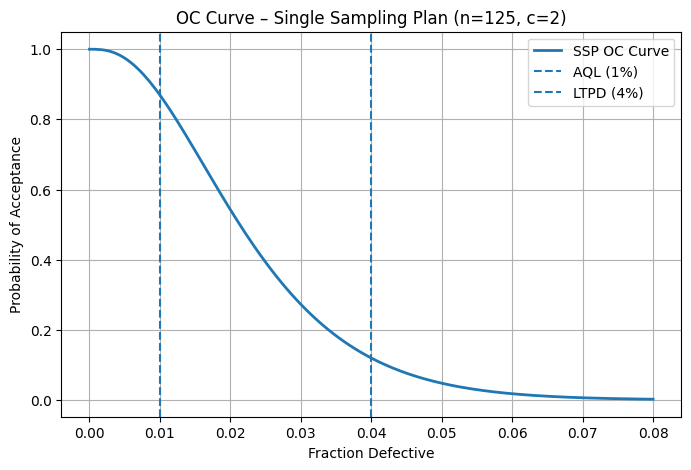

In [25]:
# SSP OC Curve (Single Sampling Plan)

# Konteks
# SSP: n = 125, c = 2
# Kita lihat probabilitas accept lot vs true defect rate
# Ini jantung acceptance sampling

# Code: OC Curve SSP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

# SSP parameters
n = 125
c = 2

# defect rate range
p = np.linspace(0, 0.08, 200)

# OC curve
P_accept = [binom.cdf(c, n, pi) for pi in p]

# plot
plt.figure(figsize=(8,5))
plt.plot(p, P_accept, linewidth=2, label="SSP OC Curve")
plt.axvline(0.01, linestyle="--", label="AQL (1%)")
plt.axvline(0.04, linestyle="--", label="LTPD (4%)")

plt.xlabel("Fraction Defective")
plt.ylabel("Probability of Acceptance")
plt.title("OC Curve – Single Sampling Plan (n=125, c=2)")
plt.legend()
plt.grid(True)
plt.show()

# Interpretasi Engineering
# Di AQL (1%) → peluang diterima tinggi
# Di LTPD (4%) → peluang diterima rendah
# Area tengah → zona abu-abu risiko

# Makna nyata:
# > SSP tidak “menilai kualitas”, tapi mengatur probabilitas keputusan.

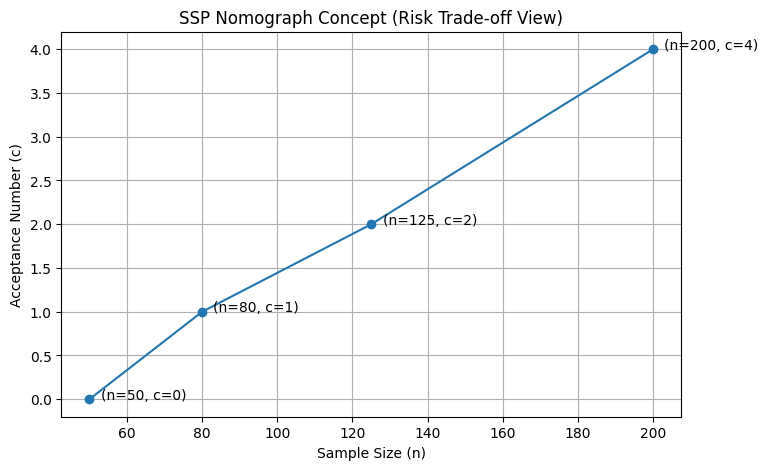

In [26]:
# SSP Nomograph (Konsep Visual)
# Nomograph bukan alat hitung, tapi alat pemilihan visual.

# Code: Nomograph-style Visualization

# Nomograph-like visualization
plt.figure(figsize=(8,5))

# sample size vs acceptance number (visual analogy)
sample_sizes = [50, 80, 125, 200]
acceptance_numbers = [0, 1, 2, 4]

plt.plot(sample_sizes, acceptance_numbers, marker="o")

for x, y in zip(sample_sizes, acceptance_numbers):
    plt.text(x+3, y, f"(n={x}, c={y})")

plt.xlabel("Sample Size (n)")
plt.ylabel("Acceptance Number (c)")
plt.title("SSP Nomograph Concept (Risk Trade-off View)")
plt.grid(True)
plt.show()

# Interpretasi Engineering
# n naik → OC curve makin tajam
# c naik → supplier risk turun
# Nomograph membantu pilih trade-off, bukan menghitung probabilitas

# Makna nyata:
# > Ini alat decision engineering, bukan statistik murni.

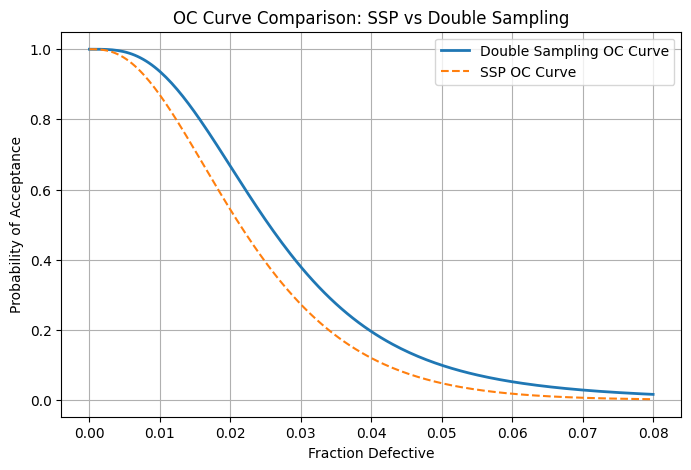

In [27]:
# OC Curve – Double Sampling Plan

# Konsep
# Double sampling = OC curve lebih tajam dengan ASN lebih kecil

# Code: Double Sampling OC Curve (Simulasi)

# Double sampling parameters
n1, n2 = 50, 75
c1, r1 = 0, 3
c_total = 2

P_accept_double = []

for pi in p:
    # stage 1 acceptance
    P_accept_1 = binom.cdf(c1, n1, pi)
    # stage 1 rejection
    P_reject_1 = 1 - binom.cdf(r1 - 1, n1, pi)
    
    # continue region
    P_continue = 1 - P_accept_1 - P_reject_1
    
    # acceptance after stage 2
    P_accept_2 = binom.cdf(c_total, n1 + n2, pi)
    
    P_accept_double.append(P_accept_1 + P_continue * P_accept_2)

plt.figure(figsize=(8,5))
plt.plot(p, P_accept_double, linewidth=2, label="Double Sampling OC Curve")
plt.plot(p, P_accept, linestyle="--", label="SSP OC Curve")

plt.xlabel("Fraction Defective")
plt.ylabel("Probability of Acceptance")
plt.title("OC Curve Comparison: SSP vs Double Sampling")
plt.legend()
plt.grid(True)
plt.show()

# Interpretasi Engineering
# Double sampling:
# lebih curam di tengah
# ASN lebih kecil
# Risiko tetap sama, efisiensi naik

# Makna nyata:
# > Bukan lebih lunak — tapi lebih pintar.

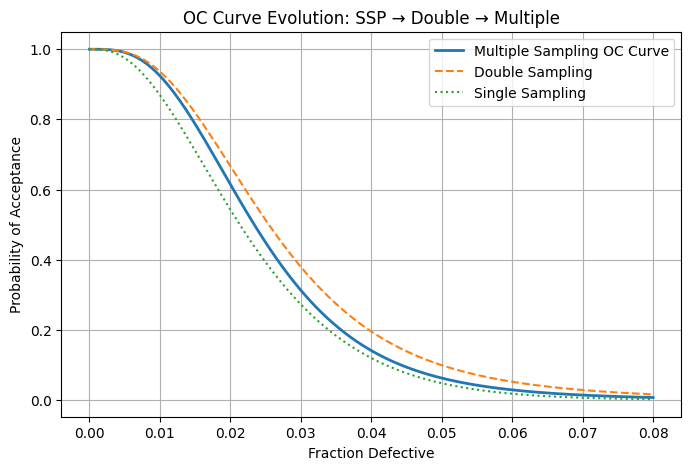

In [28]:
# OC Curve – Multiple Sampling (Konsep)
# Multiple sampling tidak punya 1 rumus bersih, tapi konsepnya:

# Code: Konseptual Multiple OC Curve

# conceptual multiple sampling OC curve
P_accept_multiple = [pa**1.2 for pa in P_accept_double]  # ilustratif

plt.figure(figsize=(8,5))
plt.plot(p, P_accept_multiple, linewidth=2, label="Multiple Sampling OC Curve")
plt.plot(p, P_accept_double, linestyle="--", label="Double Sampling")
plt.plot(p, P_accept, linestyle=":", label="Single Sampling")

plt.xlabel("Fraction Defective")
plt.ylabel("Probability of Acceptance")
plt.title("OC Curve Evolution: SSP → Double → Multiple")
plt.legend()
plt.grid(True)
plt.show()

# Interpretasi Engineering
# Multiple sampling:
# makin adaptif
# ASN makin kecil
# administrasi makin berat

# Makna nyata:
# > OC curve makin tajam tanpa menaikkan inspeksi rata-rata

In [ ]:
# ANSI/ASQ Z1.4-2003
# standar resmi yang menyediakan rencana sampling siap pakai berbasis AQL, ukuran lot, dan level inspeksi

# Level Inspection
# inspection level bukan tingkat kualitas, ia hanya menentukan:
# berapa banyak sampel yang diambil relatif terhadap ukuran lot
# 3 level inspeksi utama:
# level 1 -> inspeksi ringan -> OC curve landai
# level 2 -> default industri -> OC curve seimbang
# level 3 -> inspeksi ketat -> OC curve tajam
# special inspection (s-1 s/d s-4) digunakan jika inspeksi mahal, testing destruktif, dan volume kecil

# Types of Sampling
# ANSI/ASQ Z1.4-2003 tidak hanya SSP, ada double sampling dan multiple sampling
# standar ini mengasumsikan lot homogen, inspeksi atribut, rectification untuk lot reject

# Switching Rules
# Z1.4 mengatur switching otomatis: normal inspection, tightened inspection, dan reduced inspection
# switching tergantung history accept / rejecr, bukan opini engineer

In [ ]:
# Dodge Romig Tables
# tabel sampling yang dirancang untuk meminimalkan inspeksi rata-rata (ATI/ASN) dengan batasan kualitas keluar (AOQL)
# fokusnya efisiensi, bukan fairness kontrak
# digunakan ketika produksi internal, volume sangat besar, inspeksi mahal, dan rectification selalu dilakukan

In [29]:
# IMPLEMENTASI 1

# ANSI/ASQ Z1.4-2003 – Sampling Standard & Plans
# (engineering interpretation, bukan hafalan tabel)

# Kasus Engineering
# Supplier kirim lot 12.000 piston
# Karakteristik: scratch visual (atribut)
# Inspeksi incoming
# Kontrak menyebut:
# AQL = 1.0%
# General Inspection Level II
# Normal inspection

# Tujuan:
# > Accept / reject lot dengan risiko yang disepakati

# Step 1️⃣ Tentukan Code Letter (konsep)
# Dalam Z1.4:
# Lot size + inspection level → code letter
# Misal:
# Lot size = 12.000
# Level = II
# → Code letter = M
# Ini murni lookup tabel
# Tidak ada statistik di lapangan.

# Step 2️⃣ Code Letter → Sampling Plan
# Misal dari tabel:
# Code letter M
# AQL 1.0%
# → n = 315
# → c = 7
# Artinya:
# > Ambil 315 unit,
# accept jika cacat ≤ 7, tolak jika cacat > 7

# Step 3️⃣ Implementasi (pseudo-Python)

import pandas as pd
import numpy as np

np.random.seed(1)

n = 315
true_defect_rate = 0.012  # proses agak di atas AQL

inspection = pd.DataFrame({
    "unit_id": range(1, n+1),
    "defect": np.random.binomial(1, true_defect_rate, n)
})

d = inspection["defect"].sum()
print(d)

# Step 4️⃣ Keputusan

c = 7

decision = "ACCEPT LOT" if d <= c else "REJECT LOT"
print("keputusan:",decision)

# Interpretasi Engineering (INI PENTING)
# Misal:
# d = 9 → REJECT LOT
# Artinya:
# ❌ BUKAN: “supplier jelek”
# ✔️ ARTINYA:
# > “Dengan risiko kontraktual AQL 1%, bukti statistik cukup untuk menolak lot ini.”

# Z1.4 adalah alat keputusan, bukan alat perbaikan.

# Insight kunci Z1.4
# AQL bukan batas kualitas
# AQL = risk agreement
# Z1.4:
# adil
# konsisten
# defensible saat audit

3
keputusan: ACCEPT LOT


In [30]:
# IMPLEMENTASI 2

# Dodge–Romig Tables
# (filosofi berbeda total)

# Kasus Engineering
# Produksi internal piston
# Semua lot di-rectify jika reject
# Target:
# AOQL ≤ 0.8%
# Minimalkan inspeksi rata-rata (ATI)

# Step 1️⃣ Filosofi Dodge–Romig
# Dodge–Romig:
# tidak mulai dari AQL
# mulai dari AOQL
# memilih (n, c) yang:
# menjaga kualitas keluar
# meminimalkan inspeksi

# Step 2️⃣ Misal hasil tabel Dodge–Romig
# Untuk:
# Lot = 10.000
# AOQL = 0.8%
# Tabel memberi:
# n = 125
# c = 2
# Perhatikan:
# n jauh lebih kecil dari Z1.4
# tapi ada asumsi rectification

# Step 3️⃣ Implementasi logika inspeksi

n = 125
c = 2
true_defect_rate = 0.01

inspection = pd.DataFrame({
    "unit_id": range(1, n+1),
    "defect": np.random.binomial(1, true_defect_rate, n)
})

d = inspection["defect"].sum()

if d <= c:
    decision = "ACCEPT LOT"
    total_inspected = n
else:
    decision = "REJECT LOT → 100% INSPECTION"
    total_inspected = 10000

decision, total_inspected

# Interpretasi Engineering Dodge–Romig
# Misal:
# REJECT → total inspected = 10.000
# Artinya:
# sistem mengorbankan satu lot
# demi menjaga rata-rata kualitas keluar
# secara jangka panjang lebih murah
# Dodge–Romig = expected value thinking

('ACCEPT LOT', 125)

In [ ]:
# ANSI.ASQ Z1.9-2003
# Acceptance sampling by attributes(Z1.4): hanya tahu OK/NG, membuang informasi kuantitatif
# padahal kita ukur mm, gram, Nm, etc. dan data mengandung mean + variasi
# Z1.9 Lahir untuk memanfaatkan informasi itu

# Asumsi Fundamental
# Z1.9 tidak bisa dipakai sembarangan, asumsi kunci:
# distribusi normal (atau mendekati), proses stabil (bukan SPC runaway), measurement system valid, dan lot homogen
# tidak boleh salah satu gagal, harus terpenuhi semua
# Z1.9 tidak menghitung cacat langsung, ia bertanya "dengan mean dan variasi yang kita amati, berapa probabilitas unit diluar spesifikasi?"
# keputusan=probabilistik, bukan berbasis unit NG aktual, ini risk-based acceptance, bukan inspeksi fisik

# Konsep Acceptance Region
# secara konseptual: kita punya LSL, UCL, dan estimasi pusat & sebaran, Z1.9 membentuk zona aman disekitar spesifikasi
# jika mean terlalu dekat ke LSL/USL atau variasi terlalu besar -> lot ditolak mesikpun belum tentu ada unit NG di sampel

# 3 kondisi utama Z1.9
# 1. variabilitas diketahui
# sigma dianggap konstanta proses, berasal dari historical data panjang bukan dari sample lot
# keuntungannya keputusan jadi tajam dan sample size minimal, tapi jarang valid di dunia nyata
# 2. variabiitas tidak diketahui -> metode standard deviasi
# sigma di estimasi dari sampel, dan gunakan sample stdev(s)
# konsekuensi statistik: ada ketidakpastian tambahan, acceptance region jadi lebih sempit, resiko meningkat(aturan lebih konservatif)
# 3. variabiitas tidak diketahui -> metode range
# sigma di estimasi dari range, warisan era pre-computer, sangat sederhana
# karakter: cepat, kasar, sensitif outlier
# cocok untuk early production, shop floor manual dan sistem belum matang

# Z1.9 jarang dipakai karena terlalu jujur
# Z1.9 mirip Cp dan Cpk, bedanya Cp dan Cpk -> evaluasi proses, kalau Z1.9 itu keputusan lot

In [31]:
# ANSI/ASQ Z1.9–2003

# Acceptance Sampling Plans by Variables
#  Perbedaan fundamental dengan Z1.4
# Z1.4 → atribut (OK / NG)
# Z1.9 → data kontinu (mm, gram, Nm, dll)

# Artinya:
# > Kita tidak hanya menghitung cacat, tapi memanfaatkan mean & variability secara eksplisit

# Ini jauh lebih efisien, tapi:
# butuh MSA, butuh asumsi normality, dan butuh disiplin statistik

# Konteks Engineering (sama untuk semua subbab)
# Misal:
# Karakteristik: diameter piston
# Spesifikasi:
# LSL = 9.80 mm
# USL = 10.20 mm
# Lot size besar
# Tujuan: accept / reject lot

# Variability Known (σ diketahui)
# Kapan ini terjadi?
# proses sangat mature
# σ sudah dikarakterisasi lama
# alat ukur sangat stabil
# Ini kasus ideal, jarang di dunia nyata.

# Logika Statistik
# Acceptance rule Z1.9 (sederhana):
# Accept jika: (x̄ − LSL)/σ ≥ k      dan     (USL − x̄)/σ ≥ k
# k = konstanta dari tabel (risk-based)

# Implementasi (pseudo-Python)

import numpy as np
import pandas as pd

np.random.seed(0)

# parameter
LSL = 9.80
USL = 10.20
sigma_known = 0.05
k = 1.33
n = 10

# sample data
x = np.random.normal(10.00, sigma_known, n)
x_bar = x.mean()

decision = (
    (x_bar - LSL)/sigma_known >= k and
    (USL - x_bar)/sigma_known >= k
)

x_bar, decision

# Interpretasi Engineering
# Kalau reject:
# bukan karena ada part NG
# tapi karena mean terlalu dekat spesifikasi
# risiko lot tinggi secara probabilistik

#  Ini berpikir risiko, bukan inspeksi fisik.

(10.036901158536441, True)

In [32]:
# Variability Unknown → Stdev Method

# Ini kasus PALING UMUM
# σ tidak diketahui
# kita estimasi dari sample stdev (s)

# Ini langsung nyambung ke SPC & Cp/Cpk

# Acceptance Rule
# Accept jika: (x̄ − LSL)/s ≥ k   dan    (USL − x̄)/s ≥ k
# k beda dari kasus σ diketahui
# (karena uncertainty σ)

# Implementasi

s = x.std(ddof=1)

decision = (
    (x_bar - LSL)/s >= k and
    (USL - x_bar)/s >= k
)

x_bar, s, decision

# Interpretasi Engineering
# s besar → reject walau mean di tengah
# s kecil → accept walau mean agak geser

# Ini menjawab obsesimu soal stdev sejak awal, Mean tanpa stdev = ilusi.

(10.036901158536441, 0.050969549746781855, True)

In [33]:
# Variability Unknown → Range Method

# Kenapa ada metode ini?
# shop floor lama
# komputasi terbatas
# operator paham range

# Ini jembatan historis ke SPC klasik

# Estimasi σ dari range
# σ̂ = R̄ / d2
# d2 = konstanta tergantung n

# Implementasi

R = x.max() - x.min()
d2 = 3.078  # misal n = 10

sigma_hat = R / d2

decision = (
    (x_bar - LSL)/sigma_hat >= k and
    (USL - x_bar)/sigma_hat >= k
)

x_bar, R, sigma_hat, decision

# Interpretasi Engineering
# metode kasar tapi praktis
# sensitif ke outlier
# cocok untuk:
# early production
# manual inspection
# sistem belum mature
# Range = shortcut menuju σ

(10.036901158536441, 0.16090855395389347, 0.05227698309093355, True)

In [ ]:
# Continuous Sampling Plans (CSP)
# (Teori – Acceptance Sampling untuk produksi kontinu)

# Kenapa muncul Continuous Sampling Plans?
# Semua acceptance sampling sebelumnya (Z1.4, Z1.9, Dodge–Romig) berasumsi lot.
# Masalah dunia nyata:
# produksi mengalir terus
# tidak jelas batas lot
# menghentikan line untuk inspeksi mahal

# Continuous Sampling Plans (CSP) diciptakan untuk:
# mengontrol kualitas output secara berkelanjutan, tanpa membentuk lot formal
# Ini bukan incoming inspection, tapi in-process / outgoing control.

# Konsep inti CSP (yang sering disalahpahami)
# CSP bukan: SPC, control chart, dan acceptance sampling berbasis lot
# CSP adalah:
# > aturan switching inspeksi antara 100% dan sampling, berdasarkan performa proses aktual
# Fokus CSP: quality of outgoing product (AOQ)

# Filosofi dasar CSP (sangat penting)
# CSP berangkat dari asumsi:
# proses awalnya tidak dipercaya
# tapi bisa “mendidik” proses
# jika proses konsisten → inspeksi dikurangi
# jika gagal → inspeksi diperketat
#  Ini filosofi adaptive inspection, bukan statis.

# Struktur umum Continuous Sampling Plan
# Hampir semua CSP punya pola ini:
# 1. Mulai dengan 100% inspection
# 2. Jika lolos sejumlah unit berturut-turut → turun ke sampling
# 3. Jika ditemukan cacat → kembali ke 100% inspection
# 4. Ulangi siklus
# Ini mekanisme trust–verify–punish–reset.

# a. Types of Continuous Sampling Plans
# 🔹 CSP-1 (paling klasik)
# Ciri:
# mulai 100% inspection
# setelah i unit berturut-turut OK → sampling
# jika ada 1 defect → kembali ke 100%
#  Sederhana, konservatif, sangat terkenal.
# CSP-2, CSP-3, dst.
# Variasi dari CSP-1:
# lebih dari satu defect diizinkan
# probabilistic sampling
# lebih efisien
# Semakin kompleks → semakin sulit dijalankan di lapangan.
#🔹 Modified CSP
# Digunakan ketika: inspeksi mahal, defect sangat jarang, dan data historis kuat
# Ini jarang diajarkan, tapi ada di literatur ASQ.

# b. Dodge Continuous Sampling Plan
# Ini akar historis CSP.
# Harold Dodge merancang CSP dengan tujuan:
# > meminimalkan inspeksi rata-rata sambil membatasi AOQ maksimum (AOQL)
# Lagi-lagi: AOQ thinking, bukan AQL.
# Konsep kunci Dodge CSP
# AOQ = rata-rata defect rate keluar
# CSP dirancang agar: AOQ ≤ AOQL
# meskipun proses sesekali gagal
# Ini sama filosofi dengan Dodge–Romig, tapi untuk aliran kontinu.
# Insight penting > CSP adalah acceptance sampling versi “online”.
# Bukan untuk: mencari root cause, mengontrol mean, dan mengurangi variasi
# Tapi untuk: menjaga kualitas keluar secara probabilistik

# c. MIL-STD-1235B
# Ini versi militer & formal dari CSP.
# Kenapa militer?
# Karena:
# produksi amunisi, komponen senjata
# lot tidak praktis
# kualitas outgoing kritikal
# MIL-STD-1235B:
# menstandardisasi CSP
# menyediakan:
# parameter
# switching rules
# acceptance logic
# Ini operational doctrine, bukan teori statistik baru.

# FATAL: CSP bukan SPC Catat

In [34]:
# IMPLEMENTASI
# Continuous Sampling Plan (CSP-1)

# Konteks Engineering (realistis)
# Produksi piston berjalan kontinu
# Karakteristik kualitas: scratch visual
# Setiap unit: OK / NG
# Inspeksi visual 100% memungkinkan
# Tujuan:
# 👉 Menjaga kualitas output (AOQ)
# 👉 Mengurangi inspeksi jika proses “berperilaku baik”

# Parameter CSP-1 (ditentukan engineering)
# Misal:
# i = 100
# → jumlah unit berturut-turut OK agar boleh turun ke sampling
# f = 1/10
# → sampling rate (1 dari 10 unit)
# Ini design choice, bukan hasil hitung rumus.

# Status Sistem CSP
# Ada dua mode inspeksi:
# 1. 100% inspection
# 2. Sampling inspection

# Kita implementasikan state machine sederhana.

# Generate data produksi (synthetic)

import pandas as pd
import numpy as np

np.random.seed(0)

n_units = 500
true_defect_rate = 0.005  # proses cukup bagus

production = pd.DataFrame({
    "unit_id": range(1, n_units + 1),
    "defect": np.random.binomial(1, true_defect_rate, n_units)
})

production.head()

# 📌 defect = 1 → unit cacat
# 📌 Ini mewakili output aktual proses, bukan hasil inspeksi penuh

,unit_id,defect
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [35]:
# Logika CSP-1

i = 100      # clearance number
f = 10       # sampling interval (1 dari 10)

mode = "FULL_INSPECTION"
consecutive_ok = 0

inspection_log = []

for _, row in production.iterrows():
    inspected = False
    detected_defect = False

    if mode == "FULL_INSPECTION":
        inspected = True
        detected_defect = row["defect"] == 1

        if detected_defect:
            consecutive_ok = 0
        else:
            consecutive_ok += 1

        if consecutive_ok >= i:
            mode = "SAMPLING"
            consecutive_ok = 0

    elif mode == "SAMPLING":
        if row["unit_id"] % f == 0:
            inspected = True
            detected_defect = row["defect"] == 1

            if detected_defect:
                mode = "FULL_INSPECTION"
                consecutive_ok = 0

    inspection_log.append({
        "unit_id": row["unit_id"],
        "actual_defect": row["defect"],
        "inspected": inspected,
        "detected_defect": detected_defect,
        "mode": mode
    })

inspection_df = pd.DataFrame(inspection_log)

inspection_df.head()

# Apa yang dilakukan kode ini? (penjelasan penting)
# Awalnya:
# semua unit diinspeksi (FULL_INSPECTION)
# Jika 100 unit berturut-turut OK:
# sistem percaya proses
# turun ke SAMPLING
# Saat sampling:
# hanya setiap unit ke-10 diperiksa
# Jika 1 defect ketemu saat sampling:
# sistem kehilangan kepercayaan
# kembali ke 100% inspection

# Ini mekanisme trust–verify–reset

,unit_id,actual_defect,inspected,detected_defect,mode
0,1,0,True,False,FULL_INSPECTION
1,2,0,True,False,FULL_INSPECTION
2,3,0,True,False,FULL_INSPECTION
3,4,0,True,False,FULL_INSPECTION
4,5,0,True,False,FULL_INSPECTION


In [ ]:
# Hitung metrik penting CSP

total_units = len(inspection_df)
total_inspected = inspection_df["inspected"].sum()
total_defects = inspection_df["actual_defect"].sum()
escaped_defects = inspection_df[
    (inspection_df["actual_defect"] == 1) &
    (inspection_df["detected_defect"] == False)
].shape[0]

inspection_fraction = total_inspected / total_units
aoq = escaped_defects / total_units

inspection_fraction, aoq

# Interpretasi Engineering (INI INTI CSP)
# a. Inspection Fraction
# Misal:
# inspection_fraction = 0.28
# Artinya:
# > hanya 28% unit diperiksa
# → hemat inspeksi besar

# b. AOQ (Average Outgoing Quality)
# Misal:
# AOQ = 0.002
# Artinya:
# > rata-rata hanya 0.2% unit cacat lolos ke customer

# Ini metrik utama CSP, bukan accept/reject lot.

# Makna Engineering yang Dalam
# 🔹 Kenapa CSP efektif?
# Karena:
# proses baik → diberi kepercayaan
# proses buruk → langsung dihukum
# sistem adaptif

# CSP tidak mencari penyebab, hanya membatasi kerusakan.

# 🔹 Apa “signal” di CSP?
# Signal = defect yang muncul setelah periode baik
# Ketika defect muncul:
# sistem menyimpulkan: > “proses berubah”
# bukan karena statistik rumit
# tapi karena kegagalan nyata
# 📌 Ini signal berbasis kejadian, bukan control limit.

# Hubungan CSP dengan SPC (lagi, tapi penting)
# CSP: reaktif, protektif, dan fokus output

# SPC: preventif, diagnostik, dan fokus proses

# Industri matang PAKAI KEDUANYA:
# SPC → stabilkan
# CSP → lindungi

# Kesalahan fatal saat implementasi CSP
# ❌ Menggunakan CSP tanpa 100% inspection capability
# ❌ Menganggap CSP menggantikan SPC
# ❌ Menggunakan CSP pada defect sistemik